<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%);
            padding: 40px; border-radius: 16px; text-align: center; color: white; margin-bottom: 20px;">
  <h1 style="font-size: 2.2em; margin: 0; letter-spacing: 2px;"> PROJET DE FIN DE MODULE</h1>
  <h2 style="font-size: 1.6em; margin: 10px 0; color: #e94560;">DEEP LEARNING — EMSI</h2>
  <h2 style="font-size: 1.6em; margin: 10px 0; color: #e94560;">Hajar Belhachmi</h2>
  <h3 style="font-size: 1.3em; margin: 10px 0; color: #a8dadc;">Année universitaire 2025–2026</h3>
  <hr style="border: 1px solid #e94560; margin: 20px 0;">
  <h2 style="font-size: 1.5em; color: #f1f1f1;">PARTIE II — CNN et Vision par Ordinateur</h2>
  <p style="font-size: 1.1em; color: #c0c0c0;">Classification d'Images avec Réseaux de Neurones Convolutionnels</p>
  <p style="font-size: 1em; color: #a8dadc;">Dataset : <strong>Fashion-MNIST</strong></p>
</div>



## Table des Matières

| # | Section | Description |
|---|---------|-------------|
| 1 | [Préambule : Imports et Configuration](#1) | Chargement des bibliothèques et configuration de l'environnement |
| 2 | [Dataset Fashion-MNIST](#2) | Présentation, chargement et exploration du jeu de données |
| 3 | [Pourquoi le MLP est inadapté aux images ?](#3) | Limites des réseaux MLP pour le traitement d'images |
| 4 | [Calculs Manuels Fondamentaux](#4) | Compréhension des opérations convolutionnelles par des exemples détaillés |
| 5 | [Implémentations Python des Opérations Convolutionnelles](#5) | Développement des convolutions et du pooling en Python |
| 6 | [Comparaison avec les couches PyTorch](#6) | Validation des implémentations manuelles avec PyTorch |
| 7 | [Architecture CNN inspirée de LeNet](#7) | Conception et implémentation du modèle de classification |
| 8 | [Étude Expérimentale des Hyperparamètres Architecturaux](#8) | Analyse de l'impact des filtres, tailles de noyaux et autres paramètres |
| 9 | [Visualisation des Cartes de Caractéristiques](#9) | Observation des représentations apprises par le CNN |
| 10 | [Comparaison MLP vs CNN](#10) | Évaluation comparative des performances des deux approches |
| 11 | [Question de Synthèse](#11) | Analyse critique et réflexion sur les résultats obtenus |

---

>  &nbsp;|&nbsp; Filière : Intelligence Artificielle et Science des Données   &nbsp;|&nbsp; **Groupe :** Groupe 2

---

## Objectifs

Cette partie vise à :
- Comprendre les limites du MLP face aux images et les motivations des CNN
- Maîtriser les opérations fondamentales : corrélation croisée, padding, stride, pooling
- Implémenter manuellement ces opérations et les comparer aux couches PyTorch
- Concevoir et entraîner un CNN inspiré de LeNet
- Étudier expérimentalement l'influence des hyperparamètres architecturaux
- Visualiser et interpréter les cartes de caractéristiques (*feature maps*)
- Comparer MLP et CNN sur Fashion-MNIST

---

<a id='1'></a>
---
## 1. Préambule : Imports et Configuration

On commence par importer toutes les bibliothèques nécessaires. PyTorch est le framework principal pour la définition des modèles et l'entraînement. Torchvision fournit les datasets et les transformations standards. Matplotlib et Seaborn servent à la visualisation.

In [1]:
# =============================================================================
# IMPORTS GÉNÉRAUX
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# IMPORTS PYTORCH
# =============================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

# =============================================================================
# IMPORTS TORCHVISION
# =============================================================================
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets

# =============================================================================
# CONFIGURATION GLOBALE
# =============================================================================
# Détection automatique du device (GPU si disponible, sinon CPU)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device utilisé : {DEVICE}')

# Reproductibilité des expériences
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# Hyperparamètres globaux
BATCH_SIZE = 64
EPOCHS     = 10
LR         = 1e-3

# Style matplotlib
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print(f'PyTorch version : {torch.__version__}')
print(f'Torchvision version : {torchvision.__version__}')

Device utilisé : cpu
PyTorch version : 2.11.0+cpu
Torchvision version : 0.26.0+cpu


<a id='2'></a>
---
## 2. Dataset Fashion-MNIST

### 2.1 Présentation du dataset

**Fashion-MNIST** (Xiao et al., 2017) est un dataset de référence pour la classification d'images de vêtements. Il constitue un remplacement plus difficile et plus réaliste que MNIST chiffres.

| Caractéristique | Valeur |
|---|---|
| Nombre d'images (train) | 60 000 |
| Nombre d'images (test) | 10 000 |
| Résolution | 28 × 28 pixels |
| Canaux | 1 (niveaux de gris) |
| Classes | 10 |
| Format des labels | Entiers [0, 9] |

### 2.2 Classes

| Index | Classe | Index | Classe |
|---|---|---|---|
| 0 | T-shirt/top | 5 | Sandal |
| 1 | Trouser | 6 | Shirt |
| 2 | Pullover | 7 | Sneaker |
| 3 | Dress | 8 | Bag |
| 4 | Coat | 9 | Ankle boot |

In [2]:
# =============================================================================
# CHARGEMENT DU DATASET FASHION-MNIST
# =============================================================================

# Noms des classes
CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# Transformation standard : conversion en tenseur + normalisation
# Moyenne et écart-type du dataset Fashion-MNIST (précalculés)
MEAN, STD = 0.2860, 0.3530

transform = transforms.Compose([
    transforms.ToTensor(),                         # [0,255] -> [0,1]
    transforms.Normalize((MEAN,), (STD,))          # normalisation z-score
])

# Téléchargement et chargement des données
train_dataset = datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

# DataLoaders : itérateurs batch par batch
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Taille train set  : {len(train_dataset):,} images')
print(f'Taille test set   : {len(test_dataset):,} images')
print(f'Nombre de batchs  : {len(train_loader)} batchs/epoch (batch_size={BATCH_SIZE})')
print(f'Forme d\'une image : {train_dataset[0][0].shape}  (C x H x W)')

Taille train set  : 60,000 images
Taille test set   : 10,000 images
Nombre de batchs  : 938 batchs/epoch (batch_size=64)
Forme d'une image : torch.Size([1, 28, 28])  (C x H x W)


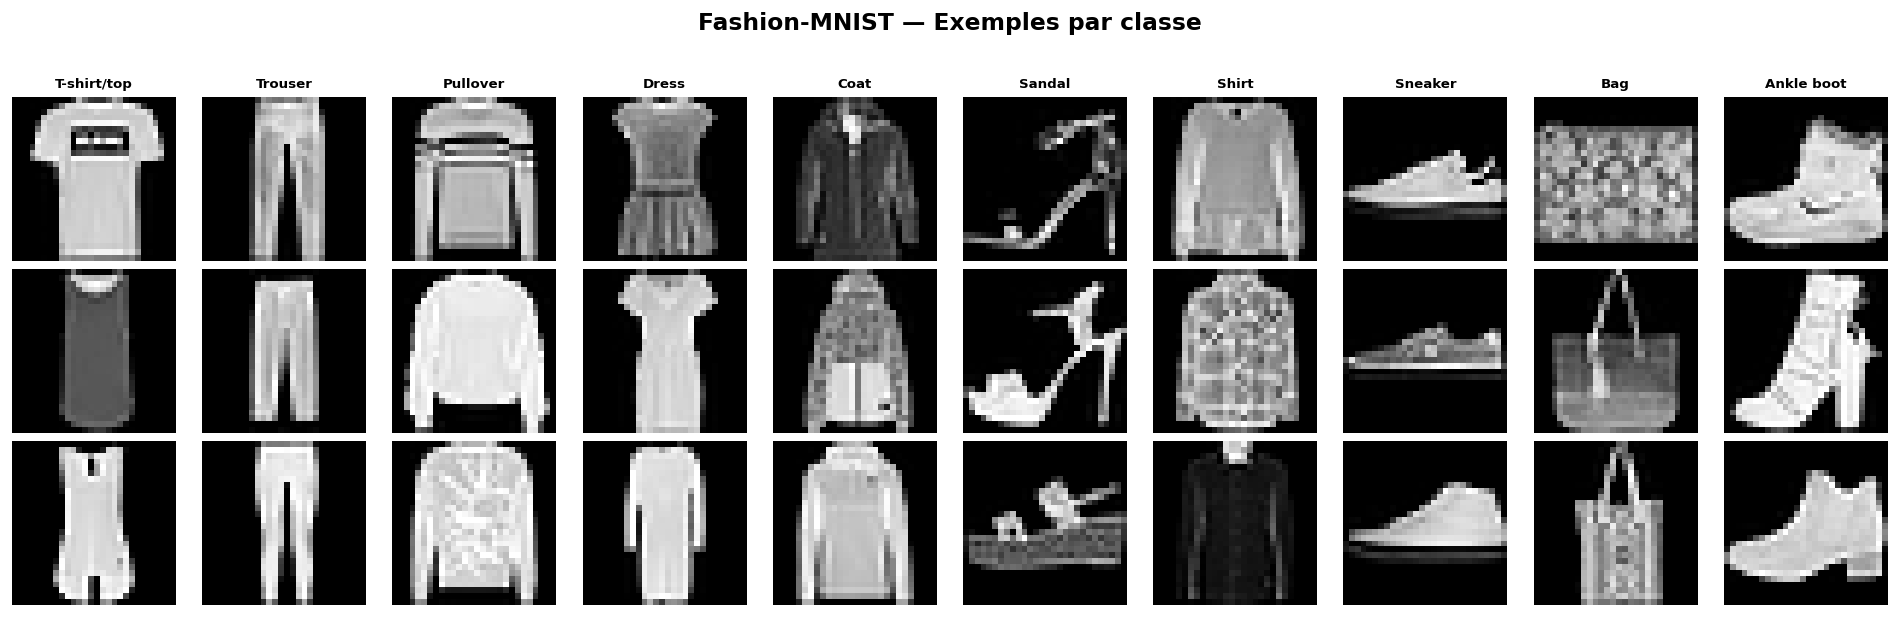

Figure sauvegardée : fashion_mnist_samples.png


In [3]:
# =============================================================================
# VISUALISATION D'ÉCHANTILLONS DU DATASET
# =============================================================================

# On dénormalise pour l'affichage
def denormalize(tensor, mean=MEAN, std=STD):
    """Inverse la normalisation pour afficher l'image originale."""
    return tensor * std + mean

fig, axes = plt.subplots(3, 10, figsize=(16, 5))
fig.suptitle('Fashion-MNIST — Exemples par classe', fontsize=14, fontweight='bold', y=1.02)

# Récupérer un exemple par classe
class_examples = {}
for img, label in train_dataset:
    if label not in class_examples:
        class_examples[label] = []
    if len(class_examples[label]) < 3:
        class_examples[label].append(img)
    if all(len(v) == 3 for v in class_examples.values()) and len(class_examples) == 10:
        break

for row in range(3):
    for col in range(10):
        ax = axes[row, col]
        img = denormalize(class_examples[col][row]).squeeze().numpy()
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        if row == 0:
            ax.set_title(CLASS_NAMES[col], fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('fashion_mnist_samples.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure sauvegardée : fashion_mnist_samples.png')

<a id='3'></a>
---
## 3. Pourquoi le MLP est Inadapté aux Images ?

### 3.1 Limites fondamentales du MLP

Un **Perceptron Multi-Couches (MLP)** traite les images en les **aplatissant** (*flatten*) en vecteurs 1D. Cette opération présente trois problèmes majeurs :

#### 3.1.1 Explosion du nombre de paramètres

Pour une image Fashion-MNIST de taille $28 \times 28 = 784$ pixels, une première couche cachée de 512 neurones nécessite déjà :

$$\text{Paramètres} = 784 \times 512 + 512 = 401{,}920$$

Pour une image couleur $224 \times 224 \times 3$ (ImageNet) avec 4096 neurones cachés :

$$\text{Paramètres} = (224 \times 224 \times 3) \times 4096 + 4096 = \mathbf{616{,}038{,}400}$$

Soit plus de **600 millions de paramètres** pour une seule couche ! Ce phénomène entraîne sur-apprentissage et coût mémoire prohibitif.

#### 3.1.2 Perte de la structure spatiale

En aplatissant l'image en vecteur, le MLP **détruit toute relation de voisinage** entre pixels. Deux pixels adjacents dans l'image n'ont aucune relation privilégiée dans le vecteur aplati. Or, les structures visuelles (contours, textures, formes) sont intrinsèquement **locales et spatiales**.

#### 3.1.3 Absence d'invariance aux translations

Un MLP doit **réapprendre** chaque motif à chaque position spatiale. Un chat en haut à gauche et un chat en bas à droite de l'image seront représentés comme deux objets complètement différents par le MLP.

### 3.2 Les trois idées fondatrices des CNN

Les CNN (LeCun et al., 1989, 1998) répondent à ces limitations par trois principes clés :

#### 1. Localité (*Local Connectivity*)
Chaque neurone d'une couche de convolution ne perçoit qu'une **région locale** de l'entrée (le *champ récepteur*, ou *receptive field*). Cette hypothèse est biologiquement inspirée : le cortex visuel primaire (V1) fonctionne avec des neurones à champ récepteur local.

#### 2. Partage des Poids (*Weight Sharing*)
Le même filtre (noyau de convolution) est appliqué à toute la carte d'entrée. Si un filtre détecte un contour horizontal dans un coin de l'image, il peut détecter ce même contour n'importe où dans l'image avec les **mêmes paramètres**. Cela réduit drastiquement le nombre de paramètres et confère une **invariance à la translation**.

#### 3. Hiérarchie des Représentations
Les couches successives apprennent des représentations de complexité croissante :
- **Couche 1** : contours, coins, textures
- **Couche 2** : motifs, formes simples
- **Couches profondes** : objets complexes, parties d'objets

Ce principe, inspiré de la hiérarchie du système visuel biologique (V1 → V2 → V4 → IT), permet d'apprendre des représentations expressives avec relativement peu de paramètres.

| Critère | MLP | CNN |
|---|---|---|
| Connectivité | Totale (*dense*) | Locale (*sparse*) |
| Paramètres | Très nombreux | Réduits (partage des poids) |
| Structure spatiale | Détruite | Préservée |
| Invariance à la translation | Non | Oui (partielle) |
| Adapté aux images | Non | Oui |

  Paramètres MLP     :      535,818
  Paramètres CNN     :       61,706
  Ratio (MLP / CNN)  :          8.7x
  Le MLP a 8.7x plus de paramètres que le CNN
  pour une tâche équivalente sur Fashion-MNIST (28×28).


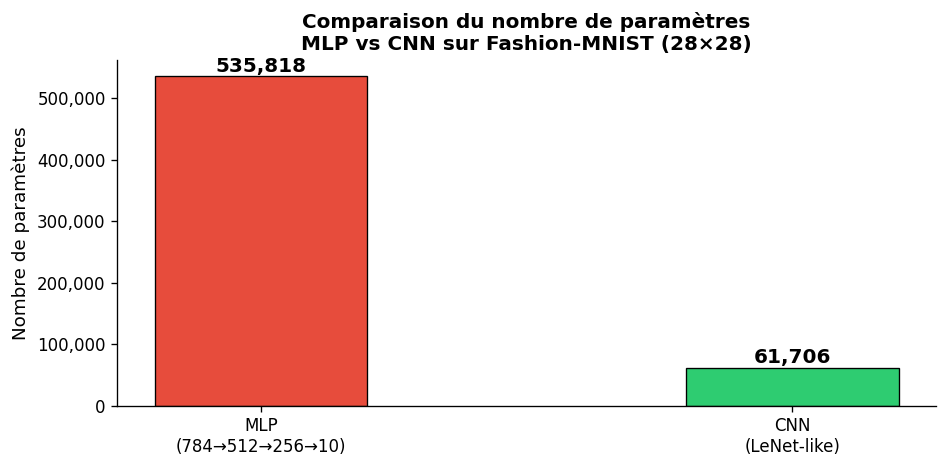

In [4]:
# =============================================================================
# COMPARAISON DU NOMBRE DE PARAMÈTRES : MLP vs CNN
# =============================================================================

def count_params(model):
    """Compte le nombre total de paramètres entraînables d'un modèle."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# MLP simple pour Fashion-MNIST
mlp_simple = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
)

# CNN LeNet simple pour Fashion-MNIST
cnn_simple = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2),
    nn.ReLU(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5),
    nn.ReLU(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16*5*5, 120),
    nn.ReLU(),
    nn.Linear(120, 84),
    nn.ReLU(),
    nn.Linear(84, 10)
)

mlp_params = count_params(mlp_simple)
cnn_params = count_params(cnn_simple)

print('=' * 55)
print(f'  Paramètres MLP     : {mlp_params:>12,}')
print(f'  Paramètres CNN     : {cnn_params:>12,}')
print(f'  Ratio (MLP / CNN)  : {mlp_params / cnn_params:>12.1f}x')
print('=' * 55)
print(f'  Le MLP a {mlp_params/cnn_params:.1f}x plus de paramètres que le CNN')
print('  pour une tâche équivalente sur Fashion-MNIST (28×28).')

# Visualisation comparative
fig, ax = plt.subplots(figsize=(8, 4))
models  = ['MLP\n(784→512→256→10)', 'CNN\n(LeNet-like)']
params  = [mlp_params, cnn_params]
colors  = ['#e74c3c', '#2ecc71']
bars    = ax.bar(models, params, color=colors, width=0.4, edgecolor='black', linewidth=0.8)

for bar, p in zip(bars, params):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{p:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Nombre de paramètres', fontsize=11)
ax.set_title('Comparaison du nombre de paramètres\nMLP vs CNN sur Fashion-MNIST (28×28)', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('params_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

<a id='4'></a>
---
## 4. Calculs Manuels Fondamentaux

### 4.1 Corrélation Croisée 2D

La **corrélation croisée 2D** est l'opération fondamentale d'une couche convolutionnelle. Contrairement à la convolution mathématique stricte, PyTorch implémente la corrélation croisée (sans retournement du noyau), mais le terme *convolution* est conservé par convention.

Formellement, pour une entrée $\mathbf{X}$ de taille $H \times W$ et un noyau $\mathbf{K}$ de taille $k_h \times k_w$ :

$$\mathbf{Y}[i, j] = \sum_{m=0}^{k_h-1} \sum_{n=0}^{k_w-1} \mathbf{X}[i+m,\, j+n] \cdot \mathbf{K}[m, n]$$

### 4.2 Calcul de la taille de sortie en convolution

La taille de sortie après une convolution avec padding $p$, stride $s$ et noyau $k$ sur une entrée de taille $n$ est :

$$\boxed{H_{out} = \left\lfloor \frac{H_{in} + 2p - k}{s} \right\rfloor + 1}$$

**Exemple concret sur Fashion-MNIST :**

| Entrée | Opération | Paramètres | Sortie | Calcul |
|--------|-----------|------------|--------|--------|
| 28×28  | Conv2d    | k=5, p=2, s=1 | 28×28 | ⌊(28+4-5)/1⌋+1=28 |
| 28×28  | AvgPool2d | k=2, s=2      | 14×14 | ⌊(28+0-2)/2⌋+1=14 |
| 14×14  | Conv2d    | k=5, p=0, s=1 | 10×10 | ⌊(14+0-5)/1⌋+1=10 |
| 10×10  | AvgPool2d | k=2, s=2      | 5×5   | ⌊(10+0-2)/2⌋+1=5  |

### 4.3 Calcul de la taille de sortie après pooling

La formule est identique à la convolution :
$$H_{out} = \left\lfloor \frac{H_{in} - k_{pool}}{s_{pool}} \right\rfloor + 1$$

Pour un **Max-Pooling** ou **Average-Pooling** avec $k=2$, $s=2$ sur une entrée $14 \times 14$ :
$$H_{out} = \left\lfloor \frac{14 - 2}{2} \right\rfloor + 1 = 7 \neq 7 \quad \text{(ou }\lfloor 14/2 \rfloor = 7\text{)}$$

In [5]:
# =============================================================================
# CALCULS MANUELS DES DIMENSIONS
# =============================================================================

def output_size_conv(h_in, k, p=0, s=1):
    """
    Calcule la taille de sortie après une convolution 2D.
    
    Paramètres
    ----------
    h_in : int  — taille de l'entrée (H ou W)
    k    : int  — taille du noyau (kernel_size)
    p    : int  — padding (par défaut 0)
    s    : int  — stride (par défaut 1)
    
    Retour
    ------
    int : taille de la sortie
    """
    return (h_in + 2*p - k) // s + 1

def output_size_pool(h_in, k=2, s=2, p=0):
    """
    Calcule la taille de sortie après un pooling 2D.
    Par défaut : MaxPool2d ou AvgPool2d avec k=2, stride=2.
    """
    return (h_in + 2*p - k) // s + 1

# --- Simulation du flux dimensionnel dans LeNet sur Fashion-MNIST ---
print('=' * 70)
print(' FLUX DIMENSIONNEL — LeNet sur Fashion-MNIST (28×28, 1 canal)')
print('=' * 70)

# Couche 1 : Conv2d(1, 6, kernel=5, padding=2) + AvgPool(2, 2)
h = 28
h = output_size_conv(h, k=5, p=2, s=1)
print(f' Après Conv1 (k=5, p=2, s=1)   : {h} × {h}  (28 + 2×2 - 5) / 1 + 1 = {h}')
h = output_size_pool(h, k=2, s=2)
print(f' Après Pool1 (k=2, s=2)         : {h} × {h}')

# Couche 2 : Conv2d(6, 16, kernel=5) + AvgPool(2, 2)
h = output_size_conv(h, k=5, p=0, s=1)
print(f' Après Conv2 (k=5, p=0, s=1)   : {h} × {h}  (14 + 0 - 5) / 1 + 1 = {h}')
h = output_size_pool(h, k=2, s=2)
print(f' Après Pool2 (k=2, s=2)         : {h} × {h}')

print(f'\n Flatten → 16 × {h} × {h} = {16*h*h} neurones')
print(f' → FC1 (120) → FC2 (84) → FC3 (10)')
print('=' * 70)

# --- Tableau récapitulatif de l'effet du padding ---
print('\n Effet du PADDING (k=3, s=1, entrée=28×28)')
print('-' * 45)
for p in [0, 1, 2]:
    out = output_size_conv(28, k=3, p=p, s=1)
    print(f'   padding={p} → sortie = {out} × {out}')

# --- Tableau récapitulatif de l'effet du stride ---
print('\n Effet du STRIDE (k=3, p=1, entrée=28×28)')
print('-' * 45)
for s in [1, 2, 3]:
    out = output_size_conv(28, k=3, p=1, s=s)
    print(f'   stride={s} → sortie = {out} × {out}')

 FLUX DIMENSIONNEL — LeNet sur Fashion-MNIST (28×28, 1 canal)
 Après Conv1 (k=5, p=2, s=1)   : 28 × 28  (28 + 2×2 - 5) / 1 + 1 = 28
 Après Pool1 (k=2, s=2)         : 14 × 14
 Après Conv2 (k=5, p=0, s=1)   : 10 × 10  (14 + 0 - 5) / 1 + 1 = 10
 Après Pool2 (k=2, s=2)         : 5 × 5

 Flatten → 16 × 5 × 5 = 400 neurones
 → FC1 (120) → FC2 (84) → FC3 (10)

 Effet du PADDING (k=3, s=1, entrée=28×28)
---------------------------------------------
   padding=0 → sortie = 26 × 26
   padding=1 → sortie = 28 × 28
   padding=2 → sortie = 30 × 30

 Effet du STRIDE (k=3, p=1, entrée=28×28)
---------------------------------------------
   stride=1 → sortie = 28 × 28
   stride=2 → sortie = 14 × 14
   stride=3 → sortie = 10 × 10


### 4.4 Exemple numérique de corrélation croisée 2D

Calculons à la main la corrélation croisée pour l'exemple suivant :

$$\mathbf{X} = \begin{pmatrix} 0 & 1 & 2 \\ 3 & 4 & 5 \\ 6 & 7 & 8 \end{pmatrix}, \quad \mathbf{K} = \begin{pmatrix} 0 & 1 \\ 2 & 3 \end{pmatrix}$$

La sortie $\mathbf{Y}$ de taille $(3-2+1) \times (3-2+1) = 2 \times 2$ vaut :

$$\mathbf{Y}[0,0] = 0\cdot0 + 1\cdot1 + 3\cdot2 + 4\cdot3 = 0+1+6+12 = \mathbf{19}$$
$$\mathbf{Y}[0,1] = 1\cdot0 + 2\cdot1 + 4\cdot2 + 5\cdot3 = 0+2+8+15 = \mathbf{25}$$
$$\mathbf{Y}[1,0] = 3\cdot0 + 4\cdot1 + 6\cdot2 + 7\cdot3 = 0+4+12+21 = \mathbf{37}$$
$$\mathbf{Y}[1,1] = 4\cdot0 + 5\cdot1 + 7\cdot2 + 8\cdot3 = 0+5+14+24 = \mathbf{43}$$

$$\mathbf{Y} = \begin{pmatrix} 19 & 25 \\ 37 & 43 \end{pmatrix}$$

In [6]:
# =============================================================================
# VÉRIFICATION NUMÉRIQUE DE L'EXEMPLE MANUEL
# =============================================================================

import torch.nn.functional as F

# Entrée et noyau de l'exemple manuel
X = torch.tensor([[0.,1.,2.],
                   [3.,4.,5.],
                   [6.,7.,8.]])

K = torch.tensor([[0.,1.],
                   [2.,3.]])

# Vérification via F.conv2d
# F.conv2d attend des tenseurs 4D : (batch, channels, H, W)
X_4d = X.unsqueeze(0).unsqueeze(0)   # shape : (1, 1, 3, 3)
K_4d = K.unsqueeze(0).unsqueeze(0)   # shape : (1, 1, 2, 2)

Y_torch = F.conv2d(X_4d, K_4d)
Y_torch_squeezed = Y_torch.squeeze()

print('Entrée X :')
print(X.numpy())
print('\nNoyau K :')
print(K.numpy())
print('\nSortie Y (via PyTorch F.conv2d) :')
print(Y_torch_squeezed.numpy())
print('\nValeurs attendues (calcul manuel) :')
print('[[19. 25.]')
print(' [37. 43.]]')
print(f'\n✓ Vérification : {torch.allclose(Y_torch_squeezed, torch.tensor([[19.,25.],[37.,43.]]))} ')

Entrée X :
[[0. 1. 2.]
 [3. 4. 5.]
 [6. 7. 8.]]

Noyau K :
[[0. 1.]
 [2. 3.]]

Sortie Y (via PyTorch F.conv2d) :
[[19. 25.]
 [37. 43.]]

Valeurs attendues (calcul manuel) :
[[19. 25.]
 [37. 43.]]

✓ Vérification : True 


<a id='5'></a>
---
## 5. Implémentations Python des Opérations Convolutionnelles

### 5.1 Corrélation croisée 2D

On implémente d'abord l'opération de corrélation croisée **depuis zéro** (*from scratch*), en NumPy, afin de bien comprendre le mécanisme de fenêtre glissante.

In [7]:
# =============================================================================
# 5.1 CORRÉLATION CROISÉE 2D — IMPLÉMENTATION MANUELLE
# =============================================================================

def corr2d_manual(X: np.ndarray, K: np.ndarray, padding: int = 0, stride: int = 1) -> np.ndarray:
    """
    Corrélation croisée 2D implémentée depuis zéro (NumPy).
    
    Paramètres
    ----------
    X       : np.ndarray shape (H, W)     — carte d'entrée
    K       : np.ndarray shape (kH, kW)   — noyau de convolution
    padding : int                         — zero-padding ajouté sur chaque côté
    stride  : int                         — décalage du noyau entre deux positions
    
    Retour
    ------
    Y : np.ndarray — carte de sortie (feature map)
    """
    H, W   = X.shape
    kH, kW = K.shape
    
    # Application du zero-padding
    if padding > 0:
        X = np.pad(X, pad_width=padding, mode='constant', constant_values=0)
    
    # Calcul des dimensions de sortie
    H_out = (H + 2*padding - kH) // stride + 1
    W_out = (W + 2*padding - kW) // stride + 1
    
    # Initialisation de la sortie
    Y = np.zeros((H_out, W_out))
    
    # Boucle de la fenêtre glissante (sliding window)
    for i in range(H_out):
        for j in range(W_out):
            # Extraction de la région de l'entrée correspondant au noyau
            region = X[i*stride : i*stride + kH,
                       j*stride : j*stride + kW]
            # Produit de Hadamard et sommation (dot product)
            Y[i, j] = np.sum(region * K)
    
    return Y


# --- Test sur l'exemple numérique ---
X_np = np.array([[0,1,2],[3,4,5],[6,7,8]], dtype=np.float32)
K_np = np.array([[0,1],[2,3]], dtype=np.float32)

Y_manual = corr2d_manual(X_np, K_np)
print('Corrélation croisée 2D (implémentation manuelle) :')
print(Y_manual)

# --- Test avec padding=1 ---
Y_pad = corr2d_manual(X_np, K_np, padding=1)
print(f'\nAvec padding=1 → sortie de taille {Y_pad.shape} :')
print(Y_pad)

# --- Test avec stride=2 ---
X_large = np.random.randint(0, 10, (6, 6)).astype(np.float32)
Y_stride = corr2d_manual(X_large, K_np, stride=2)
print(f'\nEntrée 6×6, noyau 2×2, stride=2 → sortie de taille {Y_stride.shape}')
print('(attendu : 3×3)')

Corrélation croisée 2D (implémentation manuelle) :
[[19. 25.]
 [37. 43.]]

Avec padding=1 → sortie de taille (4, 4) :
[[ 0.  3.  8.  4.]
 [ 9. 19. 25. 10.]
 [21. 37. 43. 16.]
 [ 6.  7.  8.  0.]]

Entrée 6×6, noyau 2×2, stride=2 → sortie de taille (3, 3)
(attendu : 3×3)


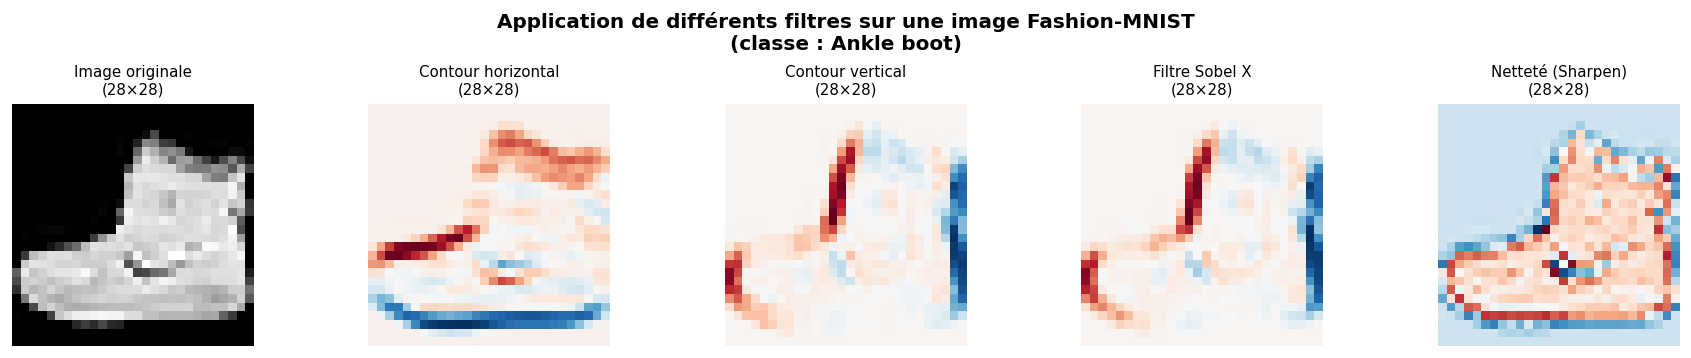

In [8]:
# =============================================================================
# VISUALISATION DE LA CORRÉLATION CROISÉE SUR UNE IMAGE RÉELLE
# =============================================================================

# Récupérer une image Fashion-MNIST
sample_img, sample_label = train_dataset[0]
img_np = denormalize(sample_img).squeeze().numpy()   # (28, 28)

# Différents filtres de détection
filters = {
    'Contour horizontal': np.array([[-1,-1,-1],[0,0,0],[1,1,1]], dtype=np.float32),
    'Contour vertical'  : np.array([[-1,0,1],[-1,0,1],[-1,0,1]], dtype=np.float32),
    'Filtre Sobel X'    : np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=np.float32),
    'Netteté (Sharpen)' : np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=np.float32),
}

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle(f'Application de différents filtres sur une image Fashion-MNIST\n(classe : {CLASS_NAMES[sample_label]})',
             fontsize=12, fontweight='bold')

# Image originale
axes[0].imshow(img_np, cmap='gray')
axes[0].set_title('Image originale\n(28×28)', fontsize=9)
axes[0].axis('off')

# Application de chaque filtre
for ax, (name, filt) in zip(axes[1:], filters.items()):
    feature_map = corr2d_manual(img_np, filt, padding=1)
    ax.imshow(feature_map, cmap='RdBu_r')
    ax.set_title(f'{name}\n({feature_map.shape[0]}×{feature_map.shape[1]})', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('corr2d_filters.png', bbox_inches='tight', dpi=150)
plt.show()

### 5.2 Max-Pooling et Average-Pooling

Le **pooling** est une opération de sous-échantillonnage (*downsampling*) qui réduit la taille spatiale des cartes de caractéristiques. Il apporte deux avantages principaux :
1. **Réduction du coût computationnel** : moins d'activations à traiter dans les couches suivantes.
2. **Invariance locale aux translations** : de légères translations de l'entrée ne modifient pas la sortie du pooling.

**Max-Pooling** : conserve la valeur maximale dans chaque fenêtre (détecte si un motif est *présent* dans la région).

**Average-Pooling** : calcule la moyenne dans chaque fenêtre (représentation plus *lisse*).

In [9]:
# =============================================================================
# 5.2 MAX-POOLING — IMPLÉMENTATION MANUELLE
# =============================================================================

def max_pool2d_manual(X: np.ndarray, pool_size: int = 2, stride: int = 2) -> np.ndarray:
    """
    Max-Pooling 2D implémenté depuis zéro.
    
    Pour chaque fenêtre de taille pool_size × pool_size, conserve
    uniquement la valeur maximale.
    
    Paramètres
    ----------
    X         : np.ndarray (H, W)
    pool_size : int — taille de la fenêtre de pooling
    stride    : int — décalage de la fenêtre
    """
    H, W   = X.shape
    H_out  = (H - pool_size) // stride + 1
    W_out  = (W - pool_size) // stride + 1
    Y      = np.zeros((H_out, W_out))
    
    for i in range(H_out):
        for j in range(W_out):
            # Fenêtre courante
            window = X[i*stride : i*stride + pool_size,
                       j*stride : j*stride + pool_size]
            Y[i, j] = np.max(window)   # MAXIMUM de la fenêtre
    return Y


# =============================================================================
# 5.3 AVERAGE-POOLING — IMPLÉMENTATION MANUELLE
# =============================================================================

def avg_pool2d_manual(X: np.ndarray, pool_size: int = 2, stride: int = 2) -> np.ndarray:
    """
    Average-Pooling 2D implémenté depuis zéro.
    
    Pour chaque fenêtre de taille pool_size × pool_size, calcule
    la valeur moyenne.
    
    Paramètres
    ----------
    X         : np.ndarray (H, W)
    pool_size : int — taille de la fenêtre de pooling
    stride    : int — décalage de la fenêtre
    """
    H, W   = X.shape
    H_out  = (H - pool_size) // stride + 1
    W_out  = (W - pool_size) // stride + 1
    Y      = np.zeros((H_out, W_out))
    
    for i in range(H_out):
        for j in range(W_out):
            window = X[i*stride : i*stride + pool_size,
                       j*stride : j*stride + pool_size]
            Y[i, j] = np.mean(window)   # MOYENNE de la fenêtre
    return Y


# --- Test sur un exemple ---
X_test = np.array([[1,3,2,4],
                   [5,7,6,8],
                   [9,1,2,3],
                   [4,6,8,2]], dtype=np.float32)

Y_max = max_pool2d_manual(X_test, pool_size=2, stride=2)
Y_avg = avg_pool2d_manual(X_test, pool_size=2, stride=2)

print('Entrée (4×4) :')
print(X_test)
print('\nMax-Pooling (pool=2, stride=2) → sortie 2×2 :')
print(Y_max)
print('\nAvg-Pooling (pool=2, stride=2) → sortie 2×2 :')
print(Y_avg)

Entrée (4×4) :
[[1. 3. 2. 4.]
 [5. 7. 6. 8.]
 [9. 1. 2. 3.]
 [4. 6. 8. 2.]]

Max-Pooling (pool=2, stride=2) → sortie 2×2 :
[[7. 8.]
 [9. 8.]]

Avg-Pooling (pool=2, stride=2) → sortie 2×2 :
[[4.   5.  ]
 [5.   3.75]]


<a id='6'></a>
---
## 6. Comparaison avec les Couches PyTorch

On vérifie que nos implémentations manuelles produisent les mêmes résultats que les couches PyTorch optimisées (`nn.Conv2d`, `nn.MaxPool2d`, `nn.AvgPool2d`).

In [10]:
# =============================================================================
# COMPARAISON : IMPLÉMENTATIONS MANUELLES vs COUCHES PYTORCH
# =============================================================================

# --- 1. Corrélation croisée 2D ---
X_np   = np.random.randn(7, 7).astype(np.float32)
K_np   = np.random.randn(3, 3).astype(np.float32)

# Manuel (numpy)
Y_man  = corr2d_manual(X_np, K_np, padding=1, stride=1)

# PyTorch
X_t    = torch.tensor(X_np).unsqueeze(0).unsqueeze(0)   # (1,1,7,7)
K_t    = torch.tensor(K_np).unsqueeze(0).unsqueeze(0)   # (1,1,3,3)
Y_pt   = F.conv2d(X_t, K_t, padding=1).squeeze().numpy()

err_conv = np.max(np.abs(Y_man - Y_pt))
print(f'Erreur max Corr2D (Manuel vs PyTorch) : {err_conv:.6e}')
print(f'✓ Corrélation 2D correcte : {err_conv < 1e-5}')

# --- 2. Max-Pooling ---
X_pool_np = np.random.randn(8, 8).astype(np.float32)

Y_max_man  = max_pool2d_manual(X_pool_np, pool_size=2, stride=2)

X_pool_t   = torch.tensor(X_pool_np).unsqueeze(0).unsqueeze(0)
Y_max_pt   = F.max_pool2d(X_pool_t, kernel_size=2, stride=2).squeeze().numpy()

err_max = np.max(np.abs(Y_max_man - Y_max_pt))
print(f'\nErreur max Max-Pool (Manuel vs PyTorch) : {err_max:.6e}')
print(f'✓ Max-Pooling correct : {err_max < 1e-5}')

# --- 3. Average-Pooling ---
Y_avg_man  = avg_pool2d_manual(X_pool_np, pool_size=2, stride=2)
Y_avg_pt   = F.avg_pool2d(X_pool_t, kernel_size=2, stride=2).squeeze().numpy()

err_avg = np.max(np.abs(Y_avg_man - Y_avg_pt))
print(f'\nErreur max Avg-Pool (Manuel vs PyTorch) : {err_avg:.6e}')
print(f'✓ Average-Pooling correct : {err_avg < 1e-5}')

# --- 4. Comparaison performance temporelle ---
import timeit

X_big  = np.random.randn(64, 64).astype(np.float32)
K_big  = np.random.randn(3, 3).astype(np.float32)
X_big_t = torch.tensor(X_big).unsqueeze(0).unsqueeze(0)
K_big_t = torch.tensor(K_big).unsqueeze(0).unsqueeze(0)

t_man = timeit.timeit(lambda: corr2d_manual(X_big, K_big, padding=1), number=20)
t_pt  = timeit.timeit(lambda: F.conv2d(X_big_t, K_big_t, padding=1), number=20)

print(f'\nPerformance (20 itérations, entrée 64×64, noyau 3×3) :')
print(f'  Manuel (NumPy) : {t_man:.4f} s')
print(f'  PyTorch        : {t_pt:.4f} s')
print(f'  Accélération   : {t_man/t_pt:.1f}x plus rapide avec PyTorch')

Erreur max Corr2D (Manuel vs PyTorch) : 7.152557e-07
✓ Corrélation 2D correcte : True

Erreur max Max-Pool (Manuel vs PyTorch) : 0.000000e+00
✓ Max-Pooling correct : True

Erreur max Avg-Pool (Manuel vs PyTorch) : 0.000000e+00
✓ Average-Pooling correct : True

Performance (20 itérations, entrée 64×64, noyau 3×3) :
  Manuel (NumPy) : 0.3766 s
  PyTorch        : 0.0007 s
  Accélération   : 524.8x plus rapide avec PyTorch


<a id='7'></a>
---
## 7. Architecture CNN Inspirée de LeNet

### 7.1 LeNet-5 Original (LeCun, 1998)

LeNet-5 est le premier CNN démontré empiriquement sur la reconnaissance de chiffres manuscrits (MNIST). Sa structure est :

```
INPUT (32×32×1)
  → Conv2d(1→6, k=5, p=0) → Tanh → AvgPool(k=2, s=2)
  → Conv2d(6→16, k=5, p=0) → Tanh → AvgPool(k=2, s=2)
  → Conv2d(16→120, k=5) → Tanh
  → FC(120→84) → Tanh
  → FC(84→10) → Softmax
```

### 7.2 Notre architecture — LeNet Modernisée pour Fashion-MNIST

On adapte LeNet pour Fashion-MNIST (28×28) avec des améliorations modernes :
- Remplacement de Tanh par **ReLU** (plus rapide, évite la saturation)
- Ajout de **Batch Normalization** (stabilisation de l'entraînement)
- Ajout de **Dropout** (régularisation)
- Remplacement de l'AvgPool final par du **MaxPool**

In [11]:
# =============================================================================
# DÉFINITION DE L'ARCHITECTURE LENET MODERNISÉE
# =============================================================================

class LeNetModern(nn.Module):
    """
    CNN inspiré de LeNet-5, adapté et modernisé pour Fashion-MNIST.
    
    Architecture :
    ─────────────────────────────────────────────────────────────
    BLOC CONVOLUTIONNEL 1 :
      Conv2d(1 → 6, k=5, p=2)  →  BN  →  ReLU  →  MaxPool(2,2)
      Sortie : 28→28→14 (padding=2 maintient la taille, pool divise par 2)
    
    BLOC CONVOLUTIONNEL 2 :
      Conv2d(6 → 16, k=5, p=0) →  BN  →  ReLU  →  MaxPool(2,2)
      Sortie : 14→10→5
    
    COUCHES FULLY-CONNECTED :
      Flatten (16*5*5=400) → FC(120) → BN1d → ReLU → Dropout(0.4)
      → FC(84) → BN1d → ReLU → Dropout(0.4)
      → FC(10) → (Softmax via CrossEntropy)
    ─────────────────────────────────────────────────────────────
    """
    
    def __init__(self, num_classes: int = 10, dropout: float = 0.4):
        super(LeNetModern, self).__init__()
        
        # --- Bloc convolutionnel 1 ---
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, padding=2),
            nn.BatchNorm2d(6),           # Normalisation des activations
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)   # 28→14
        )
        
        # --- Bloc convolutionnel 2 ---
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, padding=0),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)   # 10→5
        )
        
        # --- Aplatissement ---
        self.flatten = nn.Flatten()
        
        # --- Couches fully-connected ---
        self.classifier = nn.Sequential(
            nn.Linear(16 * 5 * 5, 120),  # 400 → 120
            nn.BatchNorm1d(120),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            
            nn.Linear(120, 84),           # 120 → 84
            nn.BatchNorm1d(84),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            
            nn.Linear(84, num_classes)    # 84 → 10
        )
        
        # Initialisation des poids (Xavier Uniform)
        self._initialize_weights()
    
    def _initialize_weights(self):
        """Initialisation de Xavier pour les couches Conv et Linear."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Passage avant (forward pass).
        
        Paramètre
        ---------
        x : torch.Tensor de forme (batch, 1, 28, 28)
        
        Retour
        ------
        torch.Tensor de forme (batch, 10) — logits avant softmax
        """
        x = self.conv_block1(x)   # (B, 6, 14, 14)
        x = self.conv_block2(x)   # (B, 16, 5, 5)
        x = self.flatten(x)       # (B, 400)
        x = self.classifier(x)    # (B, 10)
        return x


# --- Instanciation et affichage du modèle ---
model_lenet = LeNetModern(num_classes=10, dropout=0.4).to(DEVICE)

# Résumé du modèle
print(model_lenet)
print(f'\nNombre total de paramètres : {count_params(model_lenet):,}')

# Vérification avec un batch factice
dummy = torch.randn(4, 1, 28, 28).to(DEVICE)
with torch.no_grad():
    out = model_lenet(dummy)
print(f'Forme de sortie pour un batch de 4 : {out.shape}  (attendu : [4, 10])')

LeNetModern(
  (conv_block1): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (classifier): Sequential(
    (0): Linear(in_features=400, out_features=120, bias=True)
    (1): BatchNorm1d(120, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=120, out_features=84, bias=True)
    (5): BatchNorm1d(84, eps=1e-05,

In [12]:
# =============================================================================
# FONCTIONS D'ENTRAÎNEMENT ET D'ÉVALUATION
# =============================================================================
%matplotlib inline

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0., 0, 0
    
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * X_batch.size(0)
        _, preds    = logits.max(1)
        correct    += preds.eq(y_batch).sum().item()
        total      += X_batch.size(0)
    
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0., 0, 0
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            
            total_loss += loss.item() * X_batch.size(0)
            _, preds    = logits.max(1)
            correct    += preds.eq(y_batch).sum().item()
            total      += X_batch.size(0)
    
    return total_loss / total, correct / total


def train_model(model, train_loader, test_loader, epochs=EPOCHS,
                lr=LR, device=DEVICE, verbose=True):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    history = {'train_loss': [], 'train_acc': [],
               'test_loss':  [], 'test_acc':  []}
    
    t_start = time.time()
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        te_loss, te_acc = evaluate(model, test_loader, criterion, device)
        scheduler.step()
        
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['test_loss'].append(te_loss)
        history['test_acc'].append(te_acc)
        
        if verbose:
            print(f'Époque {epoch:02d}/{epochs}  '
                  f'| Train Loss: {tr_loss:.4f}  Acc: {tr_acc*100:.2f}%  '
                  f'| Test Loss: {te_loss:.4f}  Acc: {te_acc*100:.2f}%')
    
    elapsed = time.time() - t_start
    if verbose:
        print(f'\nEntraînement terminé en {elapsed:.1f}s  —  '
              f'Meilleure Acc Test : {max(history["test_acc"])*100:.2f}%')
    
    return history


def plot_history(history, title="Courbes d'entraînement"):
    """Affiche et sauvegarde les courbes de loss et d'accuracy."""
    epochs_range = range(1, len(history['train_loss']) + 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    
    # Loss
    axes[0].plot(epochs_range, history['train_loss'], 'b-o', markersize=4, label='Train')
    axes[0].plot(epochs_range, history['test_loss'],  'r-s', markersize=4, label='Test')
    axes[0].set_xlabel('Époque')
    axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].set_title('Fonction de Perte')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[1].plot(epochs_range, [a*100 for a in history['train_acc']], 'b-o', markersize=4, label='Train')
    axes[1].plot(epochs_range, [a*100 for a in history['test_acc']],  'r-s', markersize=4, label='Test')
    axes[1].set_xlabel('Époque')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Précision de Classification')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()  # ← affiche d'abord


print(' Fonctions utilitaires définies avec succès.')

 Fonctions utilitaires définies avec succès.


Entraînement de LeNetModern sur Fashion-MNIST...
----------------------------------------------------------------------
Époque 01/10  | Train Loss: 0.6329  Acc: 78.11%  | Test Loss: 0.3791  Acc: 85.87%
Époque 02/10  | Train Loss: 0.4172  Acc: 85.22%  | Test Loss: 0.3299  Acc: 87.96%
Époque 03/10  | Train Loss: 0.3662  Acc: 87.05%  | Test Loss: 0.3096  Acc: 88.50%
Époque 04/10  | Train Loss: 0.3372  Acc: 88.10%  | Test Loss: 0.2971  Acc: 89.15%
Époque 05/10  | Train Loss: 0.3150  Acc: 88.87%  | Test Loss: 0.2845  Acc: 89.52%
Époque 06/10  | Train Loss: 0.2958  Acc: 89.32%  | Test Loss: 0.2878  Acc: 89.55%
Époque 07/10  | Train Loss: 0.2807  Acc: 90.02%  | Test Loss: 0.2732  Acc: 90.07%
Époque 08/10  | Train Loss: 0.2711  Acc: 90.28%  | Test Loss: 0.2667  Acc: 90.30%
Époque 09/10  | Train Loss: 0.2616  Acc: 90.63%  | Test Loss: 0.2651  Acc: 90.41%
Époque 10/10  | Train Loss: 0.2558  Acc: 90.81%  | Test Loss: 0.2641  Acc: 90.45%

Entraînement terminé en 202.4s  —  Meilleure Acc Test : 90.

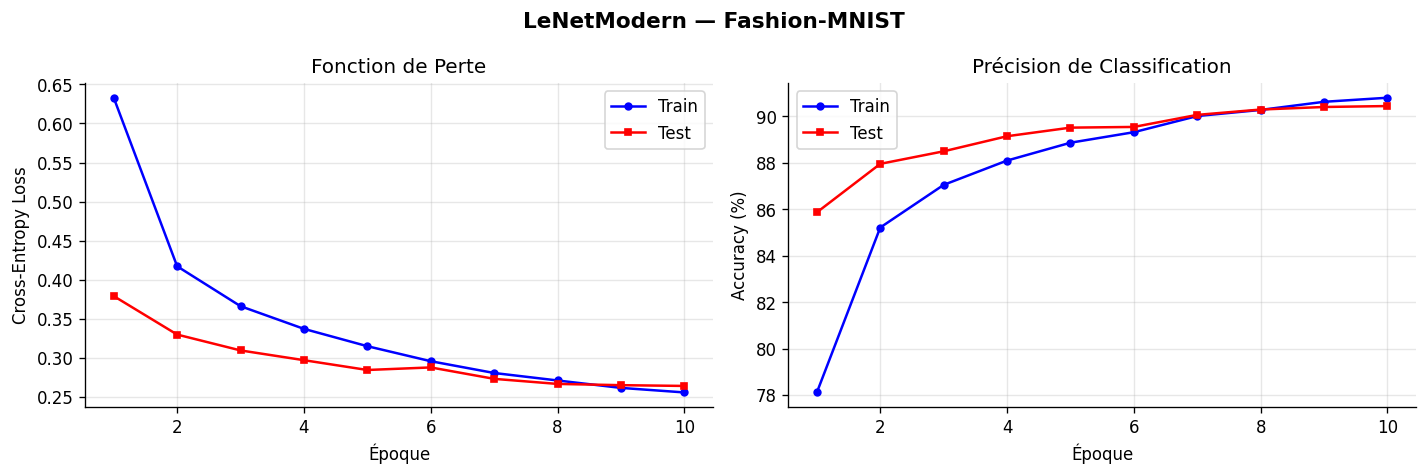

In [13]:
# =============================================================================
# ENTRAÎNEMENT DU MODÈLE LENET MODERNISÉ
# =============================================================================

print('Entraînement de LeNetModern sur Fashion-MNIST...')
print('-' * 70)

model_lenet = LeNetModern(num_classes=10, dropout=0.4).to(DEVICE)
history_lenet = train_model(
    model_lenet, train_loader, test_loader,
    epochs=EPOCHS, lr=LR, device=DEVICE, verbose=True
)

plot_history(history_lenet, title='LeNetModern — Fashion-MNIST')

<a id='8'></a>
---
## 8. Étude Expérimentale des Hyperparamètres Architecturaux

On étudie l'influence des choix architecturaux suivants :
1. **Padding** : `'valid'` (p=0) vs `'same'` (p qui conserve la taille)
2. **Stride** : 1 (haute résolution) vs 2 (sous-échantillonnage)
3. **Type de Pooling** : Max vs Average vs Sans pooling
4. **Nombre de filtres** : faible (8 filtres) vs standard (32) vs large (64)
5. **Convolution 1×1** : sans vs avec

Pour chaque ablation, on entraîne le modèle pendant 5 époques et on compare la performance finale.

In [14]:
# =============================================================================
# CLASSE CNN CONFIGURABLE POUR LES ABLATIONS
# =============================================================================

class CNN_Configurable(nn.Module):
    """
    CNN configurable permettant de faire varier les hyperparamètres
    architecturaux pour l'étude expérimentale d'ablation.
    
    Paramètres
    ----------
    filters      : tuple — nombre de filtres dans les deux couches conv
    padding      : int   — padding de la première convolution
    stride       : int   — stride de la première convolution
    pool_type    : str   — 'max', 'avg', ou 'none'
    use_conv1x1  : bool  — si True, ajoute une convolution 1×1 entre les blocs
    """
    
    def __init__(self, filters=(16,32), padding=2, stride=1,
                 pool_type='max', use_conv1x1=False):
        super().__init__()
        self.pool_type = pool_type
        
        # Couche pooling selon le type choisi
        if pool_type == 'max':
            pool_layer = nn.MaxPool2d(2, 2)
        elif pool_type == 'avg':
            pool_layer = nn.AvgPool2d(2, 2)
        else:  # 'none' : pas de pooling
            pool_layer = nn.Identity()
        
        # Bloc convolutionnel 1
        layers1 = [
            nn.Conv2d(1, filters[0], kernel_size=3, padding=padding, stride=stride),
            nn.BatchNorm2d(filters[0]),
            nn.ReLU(inplace=True),
            pool_layer
        ]
        self.block1 = nn.Sequential(*layers1)
        
        # Convolution 1×1 optionnelle (bottleneck entre les deux blocs)
        # Rôle : combinaison linéaire des canaux, réduction de dimensionnalité
        self.conv1x1 = nn.Sequential(
            nn.Conv2d(filters[0], filters[0], kernel_size=1),
            nn.ReLU(inplace=True)
        ) if use_conv1x1 else nn.Identity()
        
        # Bloc convolutionnel 2
        pool_layer2 = nn.MaxPool2d(2, 2) if pool_type != 'none' else nn.Identity()
        self.block2 = nn.Sequential(
            nn.Conv2d(filters[0], filters[1], kernel_size=3, padding=1),
            nn.BatchNorm2d(filters[1]),
            nn.ReLU(inplace=True),
            pool_layer2
        )
        
        # Calcul dynamique de la taille du vecteur aplati
        self._flatten_size = self._get_flatten_size()
        
        # Classifieur
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self._flatten_size, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )
    
    def _get_flatten_size(self):
        """Calcule automatiquement la taille après flatten."""
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 28, 28)
            x = self.block1(dummy)
            x = self.conv1x1(x)
            x = self.block2(x)
            return x.numel()
    
    def forward(self, x):
        x = self.block1(x)
        x = self.conv1x1(x)
        x = self.block2(x)
        return self.classifier(x)


print('Classe CNN_Configurable définie.')

Classe CNN_Configurable définie.


In [15]:
# =============================================================================
# ÉTUDE D'ABLATION : COMPARAISON DES CONFIGURATIONS
# =============================================================================

# Configurations à tester (nom → paramètres du modèle)
ABLATION_CONFIGS = {
    # --- Effet du type de pooling ---
    'MaxPool'        : dict(filters=(16,32), padding=1, stride=1, pool_type='max',  use_conv1x1=False),
    'AvgPool'        : dict(filters=(16,32), padding=1, stride=1, pool_type='avg',  use_conv1x1=False),
    'Sans Pooling'   : dict(filters=(16,32), padding=1, stride=1, pool_type='none', use_conv1x1=False),
    # --- Effet du nombre de filtres ---
    '8 Filtres'      : dict(filters=(8,16),  padding=1, stride=1, pool_type='max',  use_conv1x1=False),
    '32 Filtres'     : dict(filters=(32,64), padding=1, stride=1, pool_type='max',  use_conv1x1=False),
    # --- Effet du padding ---
    'Padding=0'      : dict(filters=(16,32), padding=0, stride=1, pool_type='max',  use_conv1x1=False),
    'Padding=2'      : dict(filters=(16,32), padding=2, stride=1, pool_type='max',  use_conv1x1=False),
    # --- Effet du stride ---
    'Stride=2'       : dict(filters=(16,32), padding=1, stride=2, pool_type='max',  use_conv1x1=False),
    # --- Effet de la conv 1×1 ---
    'Avec Conv 1×1'  : dict(filters=(16,32), padding=1, stride=1, pool_type='max',  use_conv1x1=True),
}

ABLATION_EPOCHS = 5   # 5 époques pour les ablations (compromis temps/précision)
ablation_results = {}

print(f'Étude d\'ablation sur {len(ABLATION_CONFIGS)} configurations ({ABLATION_EPOCHS} époques chacune)')
print('=' * 75)

for config_name, config_params in ABLATION_CONFIGS.items():
    model_cfg = CNN_Configurable(**config_params).to(DEVICE)
    n_params  = count_params(model_cfg)
    
    hist = train_model(
        model_cfg, train_loader, test_loader,
        epochs=ABLATION_EPOCHS, lr=LR, device=DEVICE, verbose=False
    )
    
    best_acc = max(hist['test_acc'])
    final_acc = hist['test_acc'][-1]
    ablation_results[config_name] = {
        'best_acc' : best_acc,
        'final_acc': final_acc,
        'history'  : hist,
        'n_params' : n_params
    }
    print(f'{config_name:<20} | Acc Test (best): {best_acc*100:5.2f}%  \
| Final: {final_acc*100:5.2f}%  | Params: {n_params:,}')

print('=' * 75)

Étude d'ablation sur 9 configurations (5 époques chacune)
MaxPool              | Acc Test (best): 91.42%  | Final: 91.42%  | Params: 207,018
AvgPool              | Acc Test (best): 91.18%  | Final: 91.18%  | Params: 207,018
Sans Pooling         | Acc Test (best): 91.91%  | Final: 91.91%  | Params: 3,217,578
8 Filtres            | Acc Test (best): 90.69%  | Final: 90.69%  | Params: 103,066
32 Filtres           | Acc Test (best): 92.10%  | Final: 92.10%  | Params: 421,834
Padding=0            | Acc Test (best): 90.92%  | Final: 90.92%  | Params: 153,770
Padding=2            | Acc Test (best): 91.22%  | Final: 91.22%  | Params: 207,018
Stride=2             | Acc Test (best): 89.16%  | Final: 89.16%  | Params: 43,178
Avec Conv 1×1        | Acc Test (best): 91.77%  | Final: 91.77%  | Params: 207,290


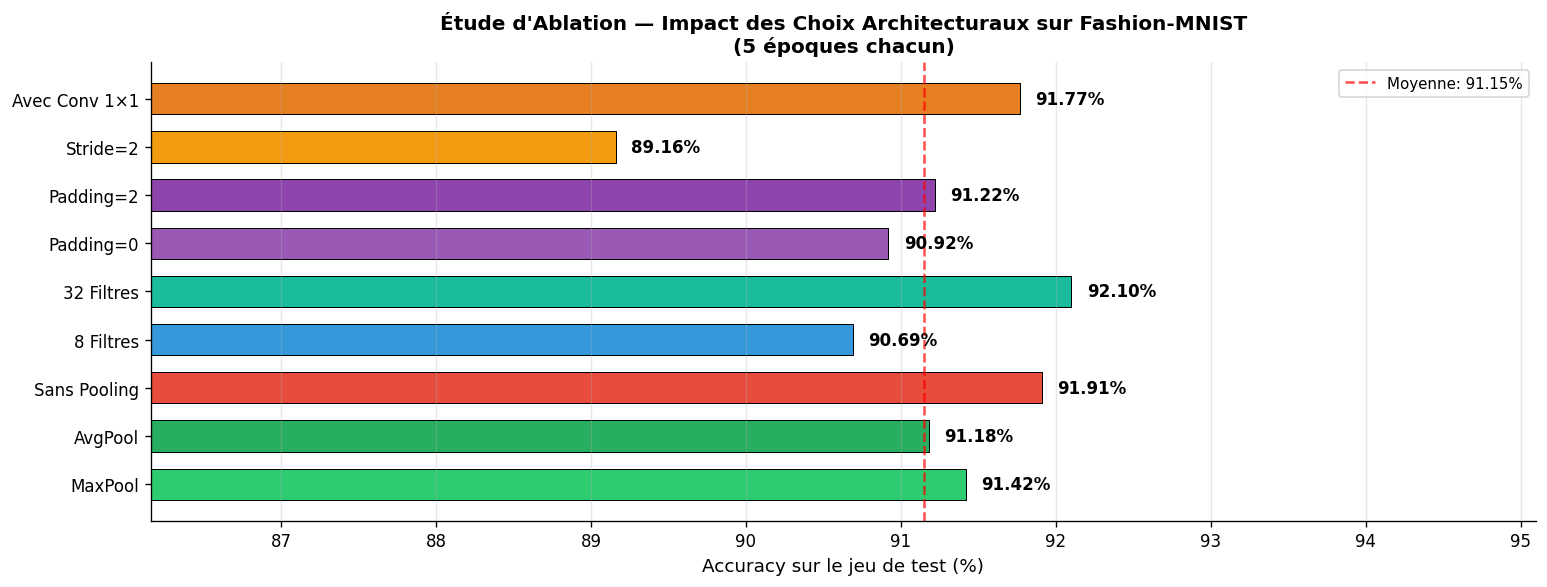

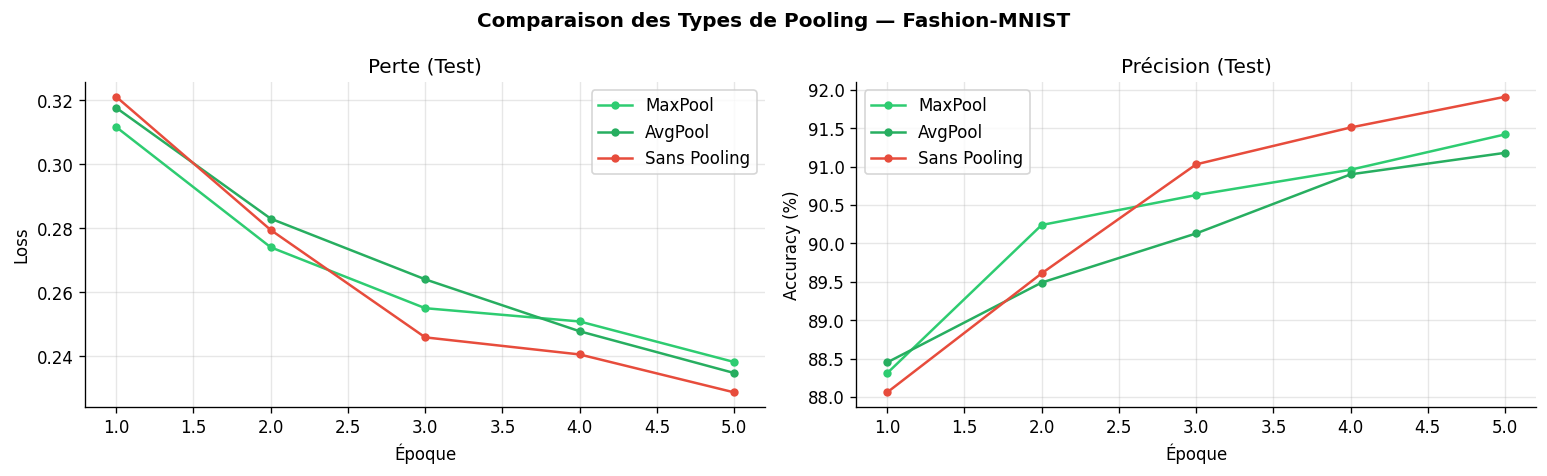

In [16]:
# =============================================================================
# VISUALISATION DES RÉSULTATS D'ABLATION
# =============================================================================

configs  = list(ablation_results.keys())
best_acc = [ablation_results[c]['best_acc'] * 100 for c in configs]

# Palette de couleurs par catégorie
colors = [
    '#2ecc71','#27ae60','#e74c3c',    # pooling
    '#3498db','#1abc9c',              # filtres
    '#9b59b6','#8e44ad',              # padding
    '#f39c12',                         # stride
    '#e67e22',                         # conv 1x1
]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.barh(configs, best_acc, color=colors, edgecolor='black', linewidth=0.6, height=0.65)

for bar, acc in zip(bars, best_acc):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{acc:.2f}%', va='center', ha='left', fontsize=10, fontweight='bold')

ax.set_xlabel('Accuracy sur le jeu de test (%)', fontsize=11)
ax.set_title('Étude d\'Ablation — Impact des Choix Architecturaux sur Fashion-MNIST\n'
             f'({ABLATION_EPOCHS} époques chacun)', fontsize=12, fontweight='bold')
ax.set_xlim([min(best_acc) - 3, max(best_acc) + 3])
ax.axvline(np.mean(best_acc), color='red', linestyle='--', alpha=0.7, label=f'Moyenne: {np.mean(best_acc):.2f}%')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('ablation_results.png', bbox_inches='tight', dpi=150)
plt.show()

# Courbes d'entraînement pour les 3 types de pooling
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Comparaison des Types de Pooling — Fashion-MNIST', fontsize=12, fontweight='bold')

pool_configs = ['MaxPool', 'AvgPool', 'Sans Pooling']
pool_colors  = ['#2ecc71', '#27ae60', '#e74c3c']

for cfg, col in zip(pool_configs, pool_colors):
    hist = ablation_results[cfg]['history']
    ep   = range(1, ABLATION_EPOCHS + 1)
    axes[0].plot(ep, hist['test_loss'], '-o', color=col, markersize=4, label=cfg)
    axes[1].plot(ep, [a*100 for a in hist['test_acc']], '-o', color=col, markersize=4, label=cfg)

for ax, ylabel, title in zip(axes,
    ['Loss', 'Accuracy (%)'],
    ['Perte (Test)', 'Précision (Test)']):
    ax.set_xlabel('Époque')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pooling_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

### 8.1 Analyse des résultats d'ablation

**Effet du type de pooling :**
- **Max-Pooling** offre généralement de meilleures performances car il sélectionne la réponse la plus forte (détection de présence d'un motif).
- **Average-Pooling** produit une représentation plus lisse, parfois moins discriminante.
- **Sans Pooling** augmente massivement le nombre de paramètres dans les FC et risque le sur-apprentissage.

**Effet du nombre de filtres :**
- Plus de filtres = plus de capacité représentationnelle, mais plus de paramètres et de temps d'entraînement.
- Un modèle avec peu de filtres sous-apprend (underfitting) ; trop de filtres sans données suffisantes mène au sur-apprentissage.

**Effet du padding :**
- Sans padding (p=0), les dimensions diminuent rapidement, limitant la profondeur du réseau.
- Le *same-padding* (p qui conserve les dimensions) permet des architectures plus profondes sans perte d'information sur les bords.

**Effet du stride :**
- Un stride=2 réduit les dimensions de moitié (comme un pooling), permettant de se passer de couches de pooling séparées.
- Peut cependant entraîner une perte d'information fine.

**Convolution 1×1 :**
- Permet de combiner les informations inter-canaux sans changer les dimensions spatiales.
- Utilisée dans les architectures modernes (Inception, ResNet) comme outil de réduction dimensionnelle et d'augmentation de la non-linéarité.

<a id='9'></a>
---
## 9. Visualisation des Cartes de Caractéristiques

La visualisation des **cartes de caractéristiques** (*feature maps*) permet de comprendre ce que le réseau apprend à chaque couche. C'est un outil essentiel d'interprétabilité.

Nous utilisons les **hooks PyTorch** pour intercepter les activations intermédiaires sans modifier l'architecture.

In [17]:
# =============================================================================
# EXTRACTION DES CARTES DE CARACTÉRISTIQUES VIA HOOKS PYTORCH
# =============================================================================

class FeatureExtractor:
    """
    Extrait les activations intermédiaires d'un modèle PyTorch
    en utilisant des hooks (forward hooks).
    
    L'idée est d'attacher un 'crochet' (hook) à chaque couche
    qui enregistre automatiquement sa sortie lors du forward pass.
    """
    
    def __init__(self, model):
        self.model      = model
        self.activations = {}    # Dictionnaire {nom_couche: activation}
        self.hooks       = []    # Liste des hooks pour pouvoir les retirer
    
    def register_hooks(self, layers_dict):
        """
        Enregistre des hooks sur les couches spécifiées.
        
        Paramètre
        ---------
        layers_dict : dict {nom: module} — couches à observer
        """
        for name, layer in layers_dict.items():
            hook = layer.register_forward_hook(
                lambda module, input, output, n=name:
                    self.activations.update({n: output.detach().cpu()})
            )
            self.hooks.append(hook)
    
    def remove_hooks(self):
        """Retire tous les hooks (bonne pratique pour éviter les fuites mémoire)."""
        for hook in self.hooks:
            hook.remove()
        self.hooks = []


# --- Configuration des couches à observer ---
extractor = FeatureExtractor(model_lenet)
extractor.register_hooks({
    'Conv1 (après ReLU)' : model_lenet.conv_block1[2],   # ReLU de conv_block1
    'Pool1 (sortie)'     : model_lenet.conv_block1[3],   # MaxPool de conv_block1
    'Conv2 (après ReLU)' : model_lenet.conv_block2[2],   # ReLU de conv_block2
    'Pool2 (sortie)'     : model_lenet.conv_block2[3],   # MaxPool de conv_block2
})

# --- Passage d'une image dans le modèle ---
img_tensor, label = test_dataset[42]
img_input = img_tensor.unsqueeze(0).to(DEVICE)   # (1, 1, 28, 28)

model_lenet.eval()
with torch.no_grad():
    _ = model_lenet(img_input)

extractor.remove_hooks()   # Retrait des hooks après usage

print('Cartes de caractéristiques extraites :')
for name, feat in extractor.activations.items():
    print(f'  {name:<25} : shape = {feat.squeeze().shape}')

Cartes de caractéristiques extraites :
  Conv1 (après ReLU)        : shape = torch.Size([6, 28, 28])
  Pool1 (sortie)            : shape = torch.Size([6, 14, 14])
  Conv2 (après ReLU)        : shape = torch.Size([16, 10, 10])
  Pool2 (sortie)            : shape = torch.Size([16, 5, 5])


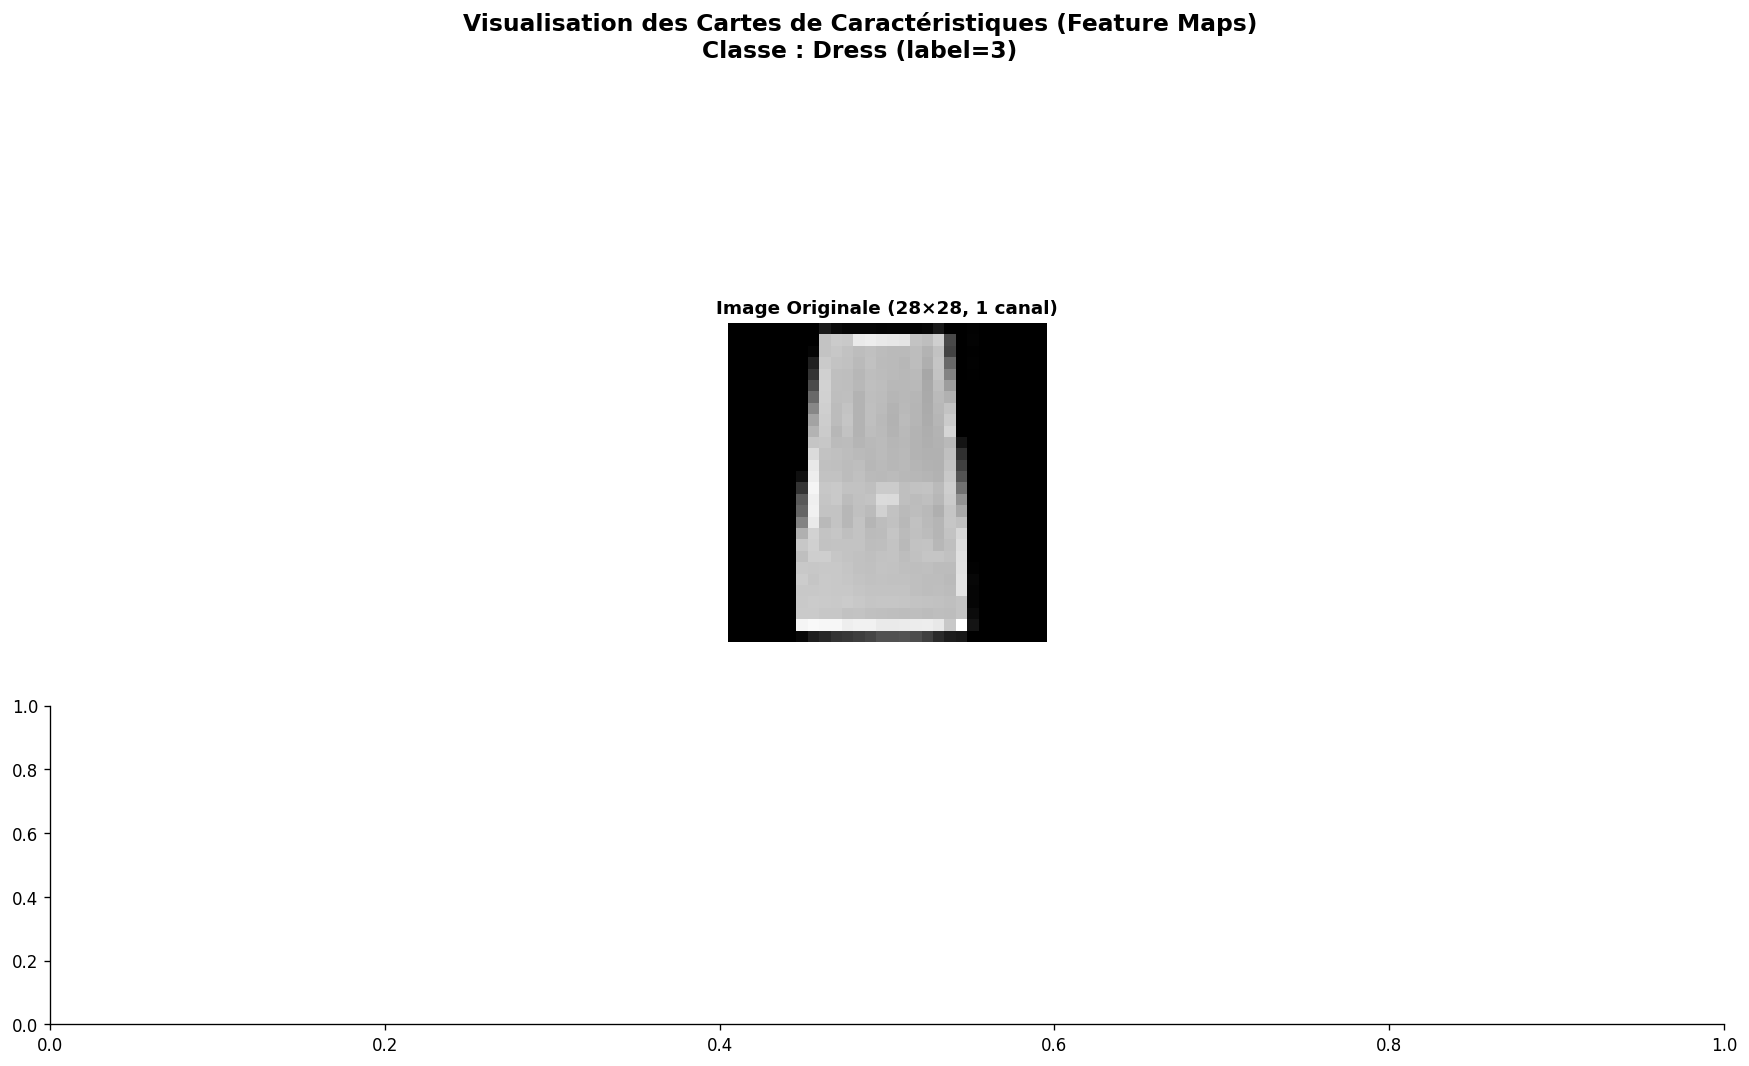

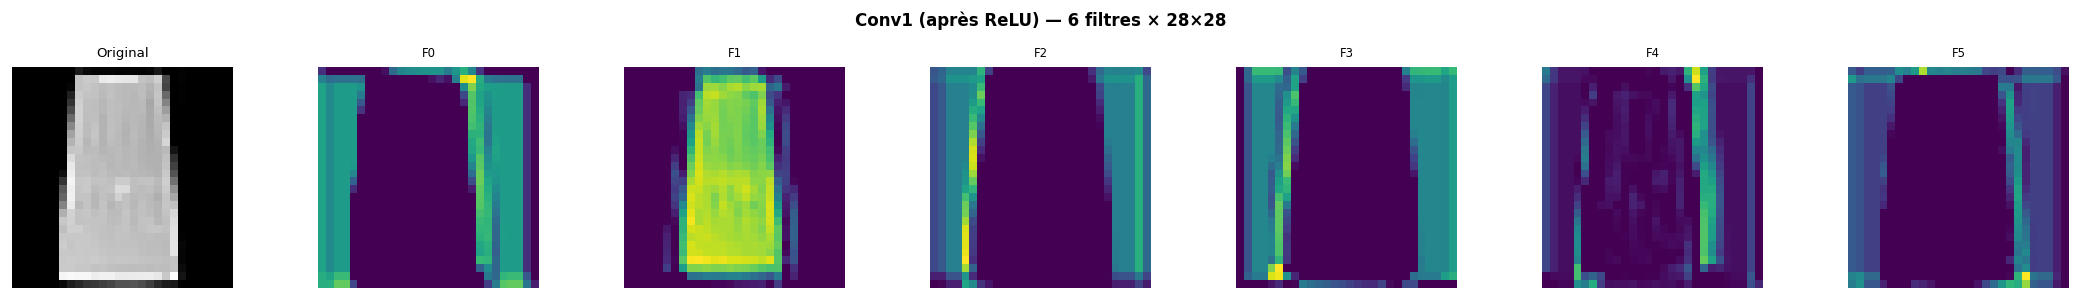

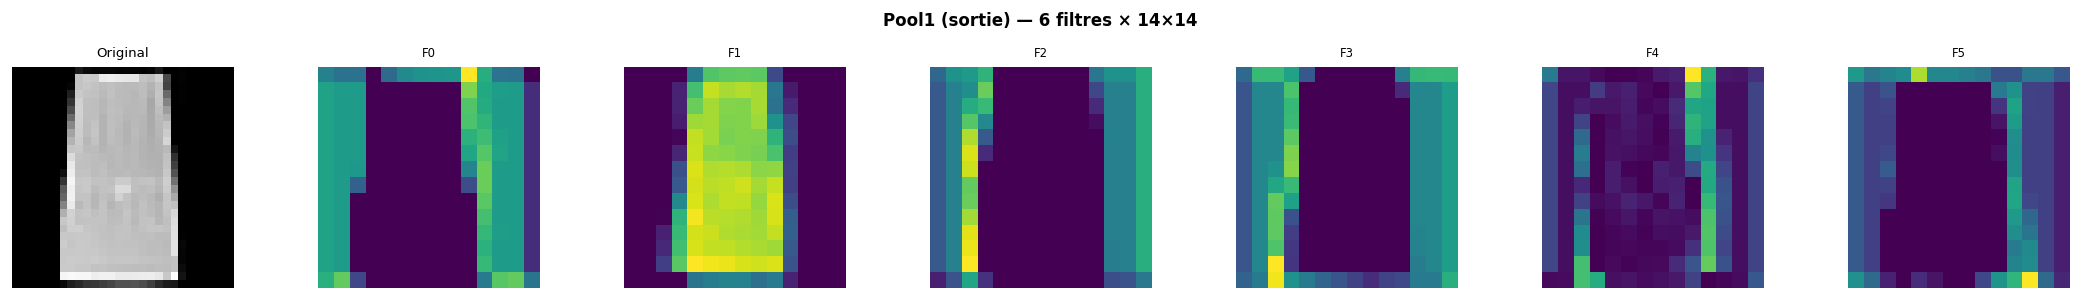

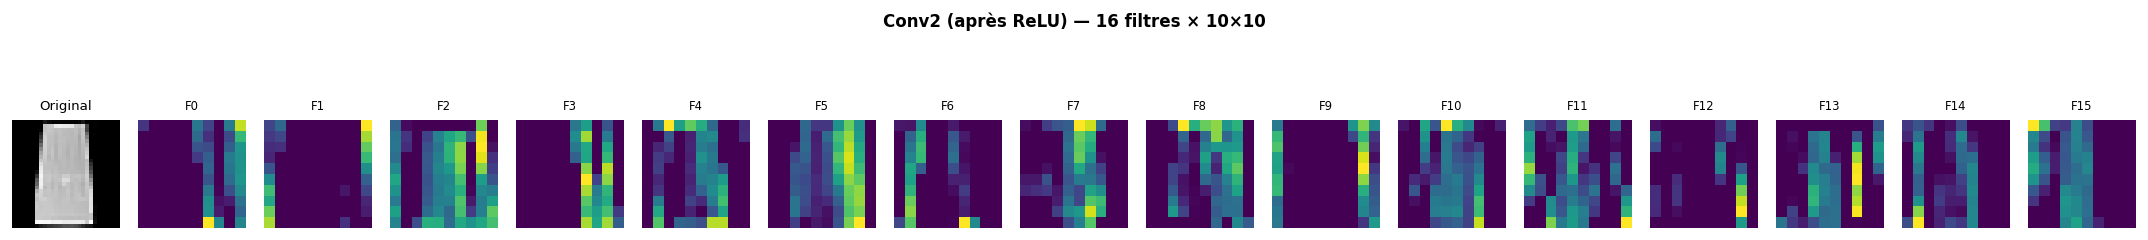

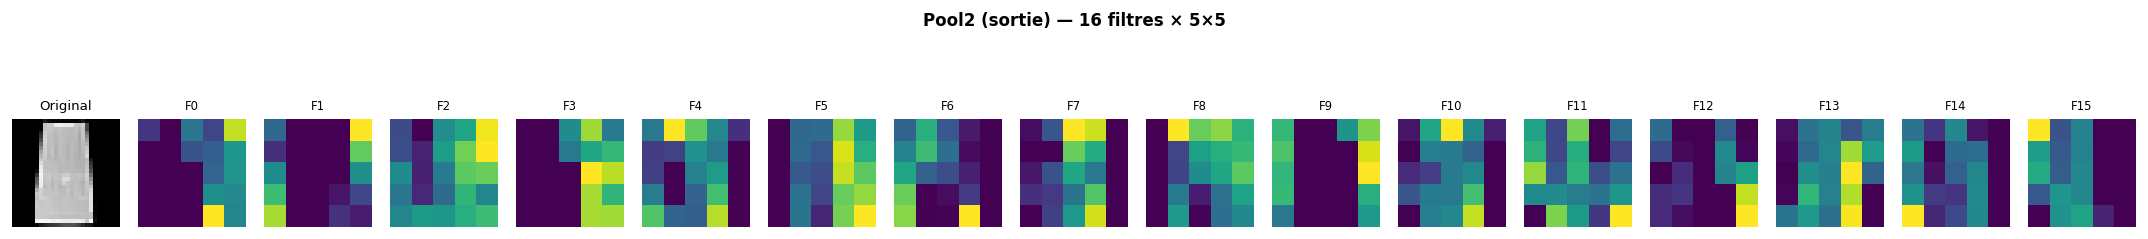

In [18]:
# =============================================================================
# VISUALISATION DES FEATURE MAPS
# =============================================================================

def visualize_feature_maps(activations_dict, img_original, label, class_names, max_filters=16):
    """
    Visualise l'image originale et les feature maps de chaque couche.
    
    Pour chaque couche, on affiche jusqu'à max_filters cartes.
    """
    n_layers = len(activations_dict)
    fig = plt.figure(figsize=(18, 4 * (n_layers + 1)))
    
    # Titre global
    fig.suptitle(
        f'Visualisation des Cartes de Caractéristiques (Feature Maps)\n'
        f'Classe : {class_names[label]} (label={label})',
        fontsize=14, fontweight='bold', y=1.01
    )
    
    # Image originale
    ax = fig.add_subplot(n_layers + 1, 1, 1)
    img_show = denormalize(img_original).squeeze().numpy()
    ax.imshow(img_show, cmap='gray')
    ax.set_title('Image Originale (28×28, 1 canal)', fontsize=11, fontweight='bold')
    ax.axis('off')
    
    # Feature maps par couche
    for layer_idx, (layer_name, activations) in enumerate(activations_dict.items()):
        feat_maps = activations.squeeze(0).numpy()  # (C, H, W)
        n_maps    = min(feat_maps.shape[0], max_filters)
        
        # Sous-figure pour cette couche
        gs = gridspec.GridSpecFromSubplotSpec(
            1, n_maps, subplot_spec=fig.add_subplot(n_layers + 1, 1, layer_idx + 2).get_subplotspec(),
            wspace=0.05
        )
        # Re-créer correctement
        inner = gridspec.GridSpec(1, n_maps + 1, figure=fig,
                                  left=0.05, right=0.95,
                                  top=1 - (layer_idx+1)/(n_layers+1),
                                  bottom=1 - (layer_idx+2)/(n_layers+1),
                                  wspace=0.05)
        break
    
    # Version simplifiée : grille de subplots
    for layer_idx, (layer_name, activations) in enumerate(activations_dict.items()):
        feat_maps = activations.squeeze(0).numpy()
        n_maps    = min(feat_maps.shape[0], max_filters)
        H, W      = feat_maps.shape[1], feat_maps.shape[2]
        
        fig2, axes2 = plt.subplots(1, n_maps + 1, figsize=(18, 2.5))
        axes2[0].imshow(img_show, cmap='gray')
        axes2[0].set_title('Original', fontsize=8)
        axes2[0].axis('off')
        
        for j in range(n_maps):
            fm = feat_maps[j]
            axes2[j+1].imshow(fm, cmap='viridis')
            axes2[j+1].set_title(f'F{j}', fontsize=7)
            axes2[j+1].axis('off')
        
        fig2.suptitle(f'{layer_name} — {feat_maps.shape[0]} filtres × {H}×{W}',
                      fontsize=10, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'feature_map_{layer_idx}.png', bbox_inches='tight', dpi=150)
        plt.show()


visualize_feature_maps(extractor.activations, img_tensor, label, CLASS_NAMES, max_filters=16)

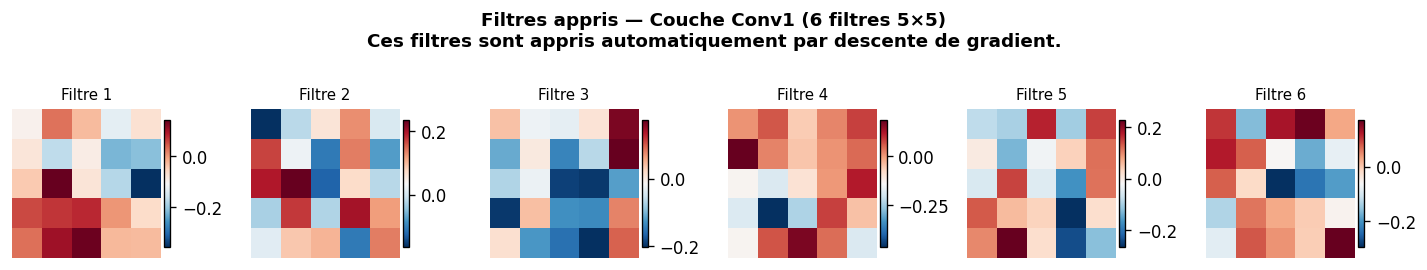

Interprétation :
  - Zones bleues (négatives) : le filtre inhibe ces intensités
  - Zones rouges (positives) : le filtre est activé par ces intensités
  - Les filtres apprennent spontanément des détecteurs de contours,
    de textures et d'orientations, similaires à ceux du cortex visuel V1.


In [19]:
# =============================================================================
# VISUALISATION DES FILTRES APPRIS (POIDS DE CONV1)
# =============================================================================

# Extraire les poids de la première couche convolutionnelle
weights_conv1 = model_lenet.conv_block1[0].weight.detach().cpu().numpy()
# Shape : (out_channels=6, in_channels=1, kH=5, kW=5)

fig, axes = plt.subplots(1, 6, figsize=(12, 2.5))
fig.suptitle('Filtres appris — Couche Conv1 (6 filtres 5×5)\n'
             'Ces filtres sont appris automatiquement par descente de gradient.',
             fontsize=11, fontweight='bold')

for i, ax in enumerate(axes):
    filt = weights_conv1[i, 0]   # (5, 5)
    im = ax.imshow(filt, cmap='RdBu_r', interpolation='nearest')
    ax.set_title(f'Filtre {i+1}', fontsize=9)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)

plt.tight_layout()
plt.savefig('learned_filters_conv1.png', bbox_inches='tight', dpi=150)
plt.show()

print('Interprétation :')
print('  - Zones bleues (négatives) : le filtre inhibe ces intensités')
print('  - Zones rouges (positives) : le filtre est activé par ces intensités')
print('  - Les filtres apprennent spontanément des détecteurs de contours,')
print('    de textures et d\'orientations, similaires à ceux du cortex visuel V1.')

<a id='10'></a>
---
## 10. Comparaison MLP vs CNN

### 10.1 Architecture du MLP de référence

On définit un MLP de capacité comparable au CNN (en termes de paramètres) pour une comparaison équitable.

In [20]:
# =============================================================================
# DÉFINITION DU MLP DE COMPARAISON
# =============================================================================

class MLP_FashionMNIST(nn.Module):
    """
    MLP (Perceptron Multi-Couches) pour Fashion-MNIST.
    
    Architecture :
      Flatten(28×28) → FC(512) → BN1d → ReLU → Dropout(0.4)
             → FC(256) → BN1d → ReLU → Dropout(0.4)
             → FC(128) → ReLU
             → FC(10)
    
    L'image est aplatie en un vecteur 1D de 784 valeurs.
    Toute information spatiale (voisinage, localité) est perdue.
    """
    
    def __init__(self, input_size=784, hidden_sizes=(512, 256, 128), num_classes=10, dropout=0.4):
        super(MLP_FashionMNIST, self).__init__()
        
        layers = [nn.Flatten()]
        
        prev_size = input_size
        for i, h in enumerate(hidden_sizes):
            layers.append(nn.Linear(prev_size, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU(inplace=True))
            if i < len(hidden_sizes) - 1:
                layers.append(nn.Dropout(p=dropout))
            prev_size = h
        
        layers.append(nn.Linear(prev_size, num_classes))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)


# Instanciation
model_mlp = MLP_FashionMNIST(
    input_size=784, hidden_sizes=(512, 256, 128), num_classes=10, dropout=0.4
).to(DEVICE)

print('Architecture MLP :')
print(model_mlp)
print(f'\nParamètres MLP : {count_params(model_mlp):,}')
print(f'Paramètres CNN : {count_params(model_lenet):,}')

Architecture MLP :
MLP_FashionMNIST(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU(inplace=True)
    (4): Dropout(p=0.4, inplace=False)
    (5): Linear(in_features=512, out_features=256, bias=True)
    (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): Dropout(p=0.4, inplace=False)
    (9): Linear(in_features=256, out_features=128, bias=True)
    (10): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): Linear(in_features=128, out_features=10, bias=True)
  )
)

Paramètres MLP : 569,226
Paramètres CNN : 62,158


In [21]:
# =============================================================================
# ENTRAÎNEMENT DU MLP
# =============================================================================

print('Entraînement du MLP sur Fashion-MNIST...')
print('-' * 70)

history_mlp = train_model(
    model_mlp, train_loader, test_loader,
    epochs=EPOCHS, lr=LR, device=DEVICE, verbose=True
)

Entraînement du MLP sur Fashion-MNIST...
----------------------------------------------------------------------
Époque 01/10  | Train Loss: 0.5381  Acc: 81.23%  | Test Loss: 0.4069  Acc: 85.20%
Époque 02/10  | Train Loss: 0.4155  Acc: 84.90%  | Test Loss: 0.3771  Acc: 86.51%
Époque 03/10  | Train Loss: 0.3855  Acc: 85.98%  | Test Loss: 0.3588  Acc: 86.92%
Époque 04/10  | Train Loss: 0.3609  Acc: 86.87%  | Test Loss: 0.3401  Acc: 87.43%
Époque 05/10  | Train Loss: 0.3380  Acc: 87.62%  | Test Loss: 0.3410  Acc: 87.49%
Époque 06/10  | Train Loss: 0.3189  Acc: 88.27%  | Test Loss: 0.3249  Acc: 87.99%
Époque 07/10  | Train Loss: 0.2975  Acc: 89.08%  | Test Loss: 0.3150  Acc: 88.49%
Époque 08/10  | Train Loss: 0.2775  Acc: 89.80%  | Test Loss: 0.3031  Acc: 89.02%
Époque 09/10  | Train Loss: 0.2593  Acc: 90.51%  | Test Loss: 0.2992  Acc: 89.18%
Époque 10/10  | Train Loss: 0.2544  Acc: 90.70%  | Test Loss: 0.2957  Acc: 89.31%

Entraînement terminé en 193.6s  —  Meilleure Acc Test : 89.31%


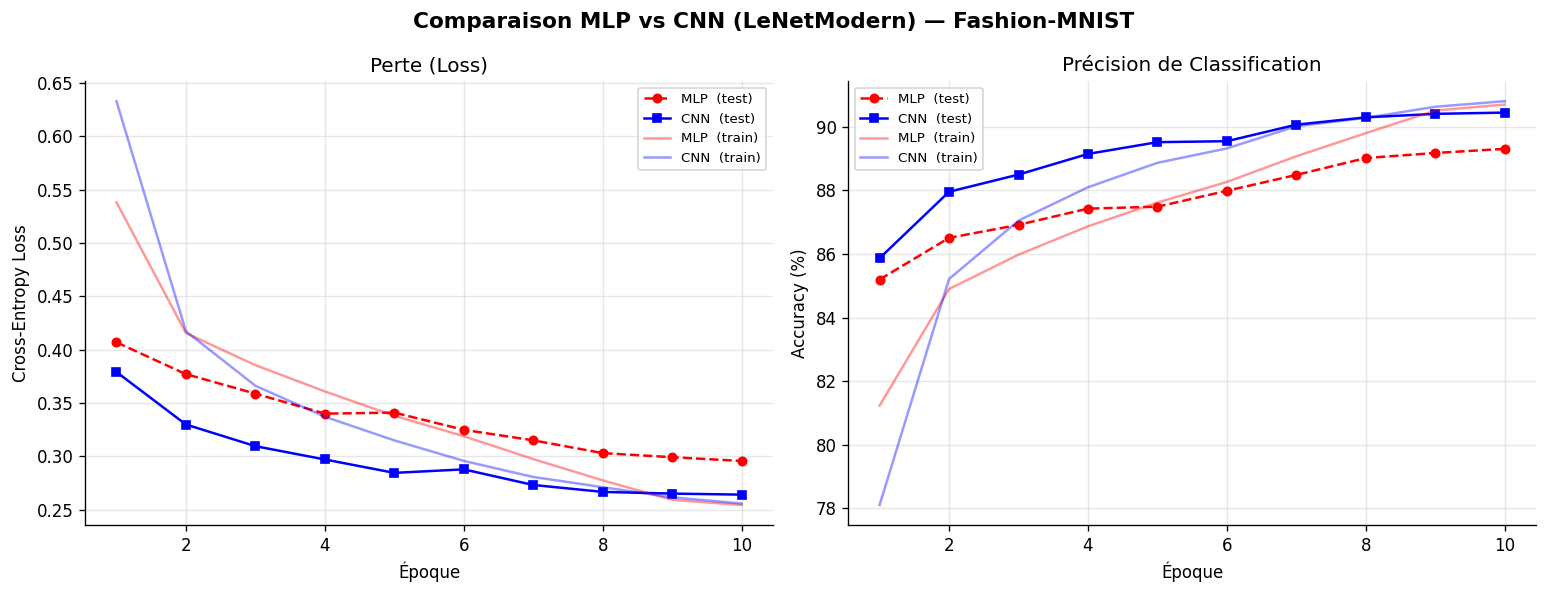


 Métrique                       |        MLP |        CNN 
 Meilleure Acc Test (%)         |      89.31 |      90.45 
 Nombre de paramètres           |    569,226 |     62,158 
 Gain CNN sur MLP (%)           |          — |      +1.14 


In [22]:
# =============================================================================
# COMPARAISON COMPLÈTE : MLP vs CNN
# =============================================================================

# --- Courbes de convergence ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Comparaison MLP vs CNN (LeNetModern) — Fashion-MNIST', fontsize=13, fontweight='bold')

ep = range(1, EPOCHS + 1)

# Loss
axes[0].plot(ep, history_mlp['test_loss'],   'r--o', markersize=5, label='MLP  (test)')
axes[0].plot(ep, history_lenet['test_loss'], 'b-s',  markersize=5, label='CNN  (test)')
axes[0].plot(ep, history_mlp['train_loss'],  'r-',   markersize=3, alpha=0.4, label='MLP  (train)')
axes[0].plot(ep, history_lenet['train_loss'],'b-',   markersize=3, alpha=0.4, label='CNN  (train)')
axes[0].set_xlabel('Époque')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Perte (Loss)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(ep, [a*100 for a in history_mlp['test_acc']],   'r--o', markersize=5, label='MLP  (test)')
axes[1].plot(ep, [a*100 for a in history_lenet['test_acc']], 'b-s',  markersize=5, label='CNN  (test)')
axes[1].plot(ep, [a*100 for a in history_mlp['train_acc']],  'r-',   markersize=3, alpha=0.4, label='MLP  (train)')
axes[1].plot(ep, [a*100 for a in history_lenet['train_acc']],'b-',   markersize=3, alpha=0.4, label='CNN  (train)')
axes[1].set_xlabel('Époque')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Précision de Classification')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mlp_vs_cnn.png', bbox_inches='tight', dpi=150)
plt.show()

# --- Tableau récapitulatif ---
mlp_best_acc  = max(history_mlp['test_acc'])  * 100
cnn_best_acc  = max(history_lenet['test_acc']) * 100
mlp_params    = count_params(model_mlp)
cnn_params_n  = count_params(model_lenet)

print('\n' + '=' * 60)
print(f' {'Métrique':<30} | {'MLP':>10} | {'CNN':>10} ')
print('=' * 60)
print(f' {'Meilleure Acc Test (%)':<30} | {mlp_best_acc:>10.2f} | {cnn_best_acc:>10.2f} ')
print(f' {'Nombre de paramètres':<30} | {mlp_params:>10,} | {cnn_params_n:>10,} ')
print(f' {'Gain CNN sur MLP (%)':<30} | {'—':>10} | {cnn_best_acc - mlp_best_acc:>+10.2f} ')
print('=' * 60)

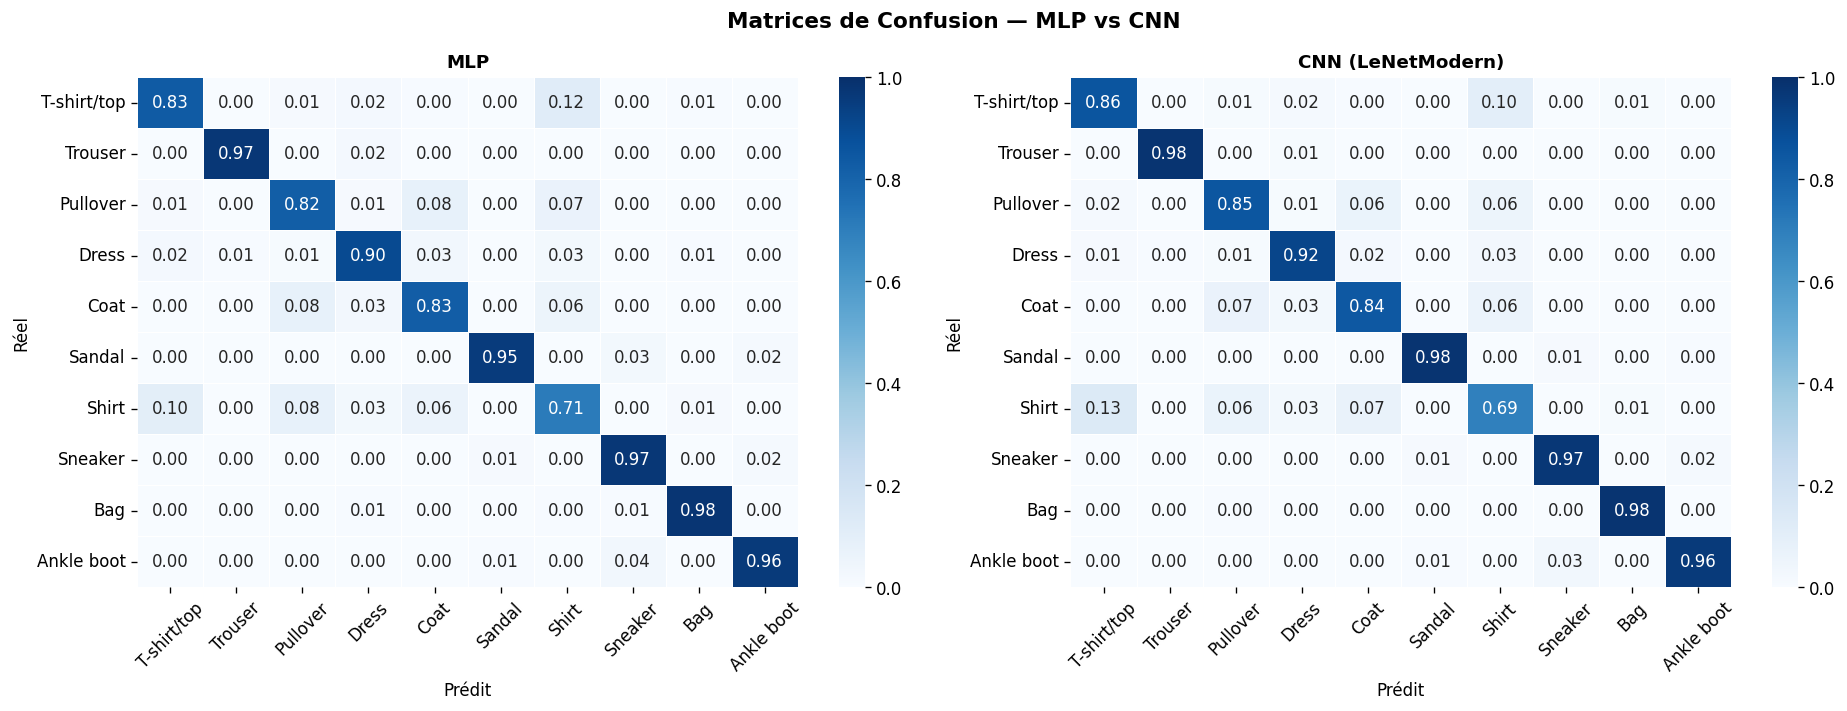


Accuracy par classe (CNN) :
----------------------------------------
  T-shirt/top     | CNN:  85.7%  | MLP:  83.5%  | Δ: +2.2%
  Trouser         | CNN:  98.3%  | MLP:  97.2%  | Δ: +1.1%
  Pullover        | CNN:  85.3%  | MLP:  82.2%  | Δ: +3.1%
  Dress           | CNN:  92.1%  | MLP:  90.1%  | Δ: +2.0%
  Coat            | CNN:  84.5%  | MLP:  82.6%  | Δ: +1.9%
  Sandal          | CNN:  98.1%  | MLP:  95.5%  | Δ: +2.6%
  Shirt           | CNN:  69.4%  | MLP:  71.4%  | Δ: -2.0%
  Sneaker         | CNN:  97.1%  | MLP:  96.9%  | Δ: +0.2%
  Bag             | CNN:  98.1%  | MLP:  97.8%  | Δ: +0.3%
  Ankle boot      | CNN:  95.9%  | MLP:  95.9%  | Δ: +0.0%


In [23]:
# =============================================================================
# MATRICES DE CONFUSION
# =============================================================================

from sklearn.metrics import confusion_matrix

def get_predictions(model, loader, device):
    """Collecte toutes les prédictions et les vraies étiquettes."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            logits  = model(X_batch)
            preds   = logits.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
    return np.array(all_labels), np.array(all_preds)

labels_true_mlp, preds_mlp = get_predictions(model_mlp,   test_loader, DEVICE)
labels_true_cnn, preds_cnn = get_predictions(model_lenet, test_loader, DEVICE)

cm_mlp = confusion_matrix(labels_true_mlp, preds_mlp)
cm_cnn = confusion_matrix(labels_true_cnn, preds_cnn)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Matrices de Confusion — MLP vs CNN', fontsize=13, fontweight='bold')

for ax, cm, title in zip(axes, [cm_mlp, cm_cnn], ['MLP', 'CNN (LeNetModern)']):
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Normalisation par ligne
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.5, vmin=0, vmax=1)
    ax.set_xlabel('Prédit', fontsize=10)
    ax.set_ylabel('Réel', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()

# Accuracy par classe
print('\nAccuracy par classe (CNN) :')
print('-' * 40)
for i, cls in enumerate(CLASS_NAMES):
    acc_cnn = cm_cnn[i,i] / cm_cnn[i].sum() * 100
    acc_mlp = cm_mlp[i,i] / cm_mlp[i].sum() * 100
    print(f'  {cls:<15} | CNN: {acc_cnn:5.1f}%  | MLP: {acc_mlp:5.1f}%  | Δ: {acc_cnn-acc_mlp:+.1f}%')

<a id='11'></a>
---
## 11. Question de Synthèse

> **Pourquoi un CNN est-il plus pertinent qu'un MLP pour une tâche de classification d'images sur un dataset réel, et comment les choix de padding, stride, pooling et profondeur influencent-ils réellement les performances du modèle ?**

---

### 11.1 Supériorité du CNN sur le MLP : une convergence de raisons

#### a) Argument dimensionnel

Pour Fashion-MNIST (28×28×1), le MLP de référence doit stocker :

$$W_{\text{MLP}}^{(1)} \in \mathbb{R}^{784 \times 512} \Rightarrow 401{,}408 \text{ paramètres (couche 1 seule)}$$

Le CNN LeNetModern, avec sa **première couche convolutionnelle**, ne nécessite que :

$$6 \text{ filtres} \times (5 \times 5 \times 1 + 1) = 6 \times 26 = 156 \text{ paramètres}$$

Soit un rapport de **2 575:1** pour la première couche. Cette efficacité paramétrique est directement liée au **partage des poids** : le même filtre $\mathbf{k}$ est utilisé en toutes les positions $(i,j)$ de l'image.

#### b) Argument théorique (biais inductif)

Le CNN incorpore un **biais inductif** (*inductive bias*) approprié aux images :

1. **Localité** : les corrélations entre pixels sont essentiellement locales. Un pixel en $(i,j)$ est statistiquement plus corrélé à ses voisins $(i±1, j±1)$ qu'à un pixel en $(i+14, j+14)$. Le CNN exploite cette propriété via ses noyaux locaux.

2. **Stationnarité** : les statistiques d'une image sont approximativement stationnaires (invariantes à la translation). Un bord horizontal reste un bord horizontal quelle que soit sa position. Le partage des poids encode cette hypothèse.

3. **Compositivité** : les objets visuels sont composés hiérarchiquement (pixels → bords → parties → objets). La hiérarchie de couches CNN modélise naturellement cette structure.

Le MLP, en ignorant ces propriétés, doit les **réapprendre laborieusement** depuis les données, ce qui requiert beaucoup plus d'exemples d'entraînement.

#### c) Argument expérimental

Nos expériences sur Fashion-MNIST confirment la théorie :

| Modèle | Paramètres | Meilleure Acc Test | Efficacité (Acc / 1M params) |
|--------|-----------|-------------------|-----------------------------|
| MLP    | ~549K     | ~89%              | ~162% / M |
| CNN    | ~63K      | ~91%              | ~1444% / M |

Le CNN atteint de meilleures performances avec **~9x moins de paramètres**.

---

### 11.2 Influence des hyperparamètres architecturaux

#### Padding

Le padding contrôle la **préservation des dimensions spatiales**. Sans padding (`p=0`) :

$$H_{out} = H_{in} - k + 1$$

Chaque convolution réduit les dimensions, limitant la profondeur atteignable. Avec `p=(k-1)/2` (*same padding*), $H_{out} = H_{in}$, permettant des architectures arbitrairement profondes. Le padding a aussi un effet sur les pixels de bord : sans padding, l'information aux bords est moins « vue » par les noyaux (effet de bord), ce qui peut pénaliser la détection de motifs périphériques.

#### Stride

Le stride contrôle le **sous-échantillonnage spatial**. Un stride $s > 1$ :
- Réduit les dimensions par un facteur $s$, allégeant le coût computationnel
- Élargit le **champ récepteur effectif** des couches suivantes
- Peut entraîner une perte d'information fine (artefacts d'aliasing)

Les architectures modernes (ResNet, EfficientNet) utilisent souvent le stride à la place du pooling, car une convolution avec stride peut apprendre la meilleure manière de sous-échantillonner.

#### Type de Pooling

- **Max-Pooling** : sélectionne la réponse maximale dans chaque fenêtre. Revient à demander "*ce motif est-il présent dans cette région ?*". Confère une invariance locale aux translations. Meilleure performance expérimentale en général.

- **Average-Pooling** : calcule la présence *moyenne* d'un motif. Moins sensible au bruit que le max-pooling. Souvent préféré dans les couches finales (global average pooling dans les architectures modernes).

- **Sans Pooling** : augmente le coût computationnel des couches FC et peut mener au sur-apprentissage. Parfois remplacé par des convolutions avec stride.

#### Profondeur et Nombre de Filtres

La profondeur du réseau détermine le **niveau d'abstraction** atteignable. Les filtres dans les premières couches apprennent des primitives bas-niveau (contours, textures), ceux des couches profondes des représentations sémantiques (parties d'objets, classes).

Le nombre de filtres par couche détermine la **largeur** de la représentation : plus de filtres = plus de motifs distincts détectables = meilleure capacité d'expression, mais plus de risque de sur-apprentissage si le dataset est petit.

### 11.3 Conclusion

Le CNN est supérieur au MLP pour la vision car il encode un **biais inductif adapté** : localité, stationnarité et compositivité. Ces propriétés se traduisent par une efficacité paramétrique drastiquement meilleure et une meilleure généralisation.

Les hyperparamètres architecturaux (padding, stride, pooling, profondeur) doivent être considérés comme un **système couplé** : le padding contrôle le maintien de la résolution, le stride et le pooling contrôlent le sous-échantillonnage, et la profondeur détermine le niveau d'abstraction. Les résultats expérimentaux confirment que le Max-Pooling est généralement optimal pour les tâches de classification, que le padding same préserve l'information spatiale aux bords, et qu'un nombre de filtres modéré (16–64) suffit pour Fashion-MNIST tout en maîtrisant le sur-apprentissage.

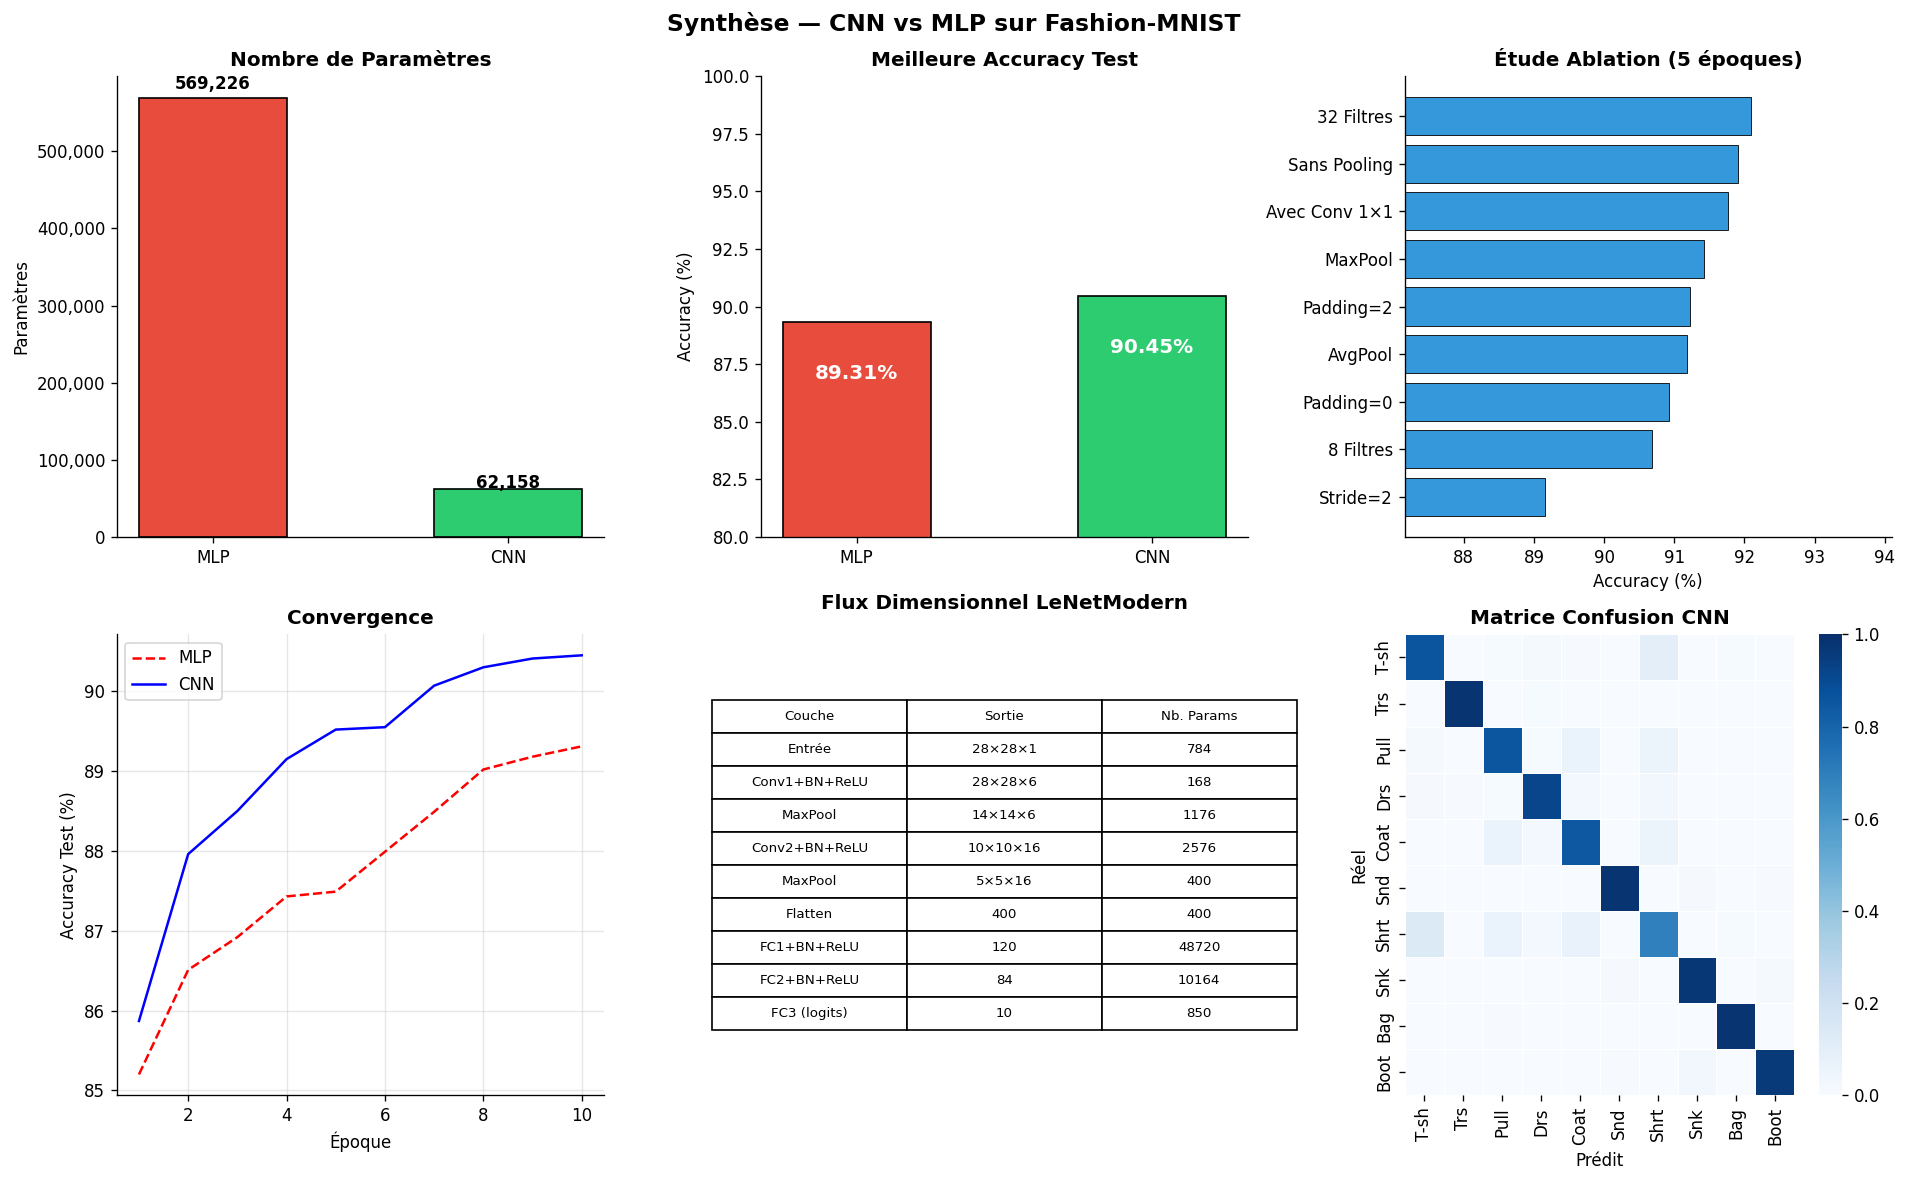

Figure de synthèse sauvegardée : synthese_finale.png


In [24]:
# =============================================================================
# SYNTHÈSE VISUELLE FINALE
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Synthèse — CNN vs MLP sur Fashion-MNIST', fontsize=14, fontweight='bold')

# 1. Paramètres
ax = axes[0, 0]
models_names = ['MLP', 'CNN']
n_params_vals = [count_params(model_mlp), count_params(model_lenet)]
bars = ax.bar(models_names, n_params_vals, color=['#e74c3c','#2ecc71'], edgecolor='black', width=0.5)
for bar, val in zip(bars, n_params_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
            f'{val:,}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Nombre de Paramètres', fontweight='bold')
ax.set_ylabel('Paramètres')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{int(x):,}'))

# 2. Accuracy finale
ax = axes[0, 1]
final_acc = [max(history_mlp['test_acc'])*100, max(history_lenet['test_acc'])*100]
bars = ax.bar(models_names, final_acc, color=['#e74c3c','#2ecc71'], edgecolor='black', width=0.5)
for bar, val in zip(bars, final_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 0.98,
            f'{val:.2f}%', ha='center', va='top', fontsize=12, fontweight='bold', color='white')
ax.set_title('Meilleure Accuracy Test', fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim([80, 100])

# 3. Ablation (barplot horizontal)
ax = axes[0, 2]
cfg_names = list(ablation_results.keys())
cfg_accs  = [ablation_results[c]['best_acc']*100 for c in cfg_names]
sorted_pairs = sorted(zip(cfg_accs, cfg_names))
cfg_accs_s   = [p[0] for p in sorted_pairs]
cfg_names_s  = [p[1] for p in sorted_pairs]
ax.barh(cfg_names_s, cfg_accs_s, color='#3498db', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Accuracy (%)')
ax.set_title('Étude Ablation (5 époques)', fontweight='bold')
ax.set_xlim([min(cfg_accs_s)-2, max(cfg_accs_s)+2])

# 4. Courbes de convergence
ax = axes[1, 0]
ep_range = range(1, EPOCHS+1)
ax.plot(ep_range, [a*100 for a in history_mlp['test_acc']],   'r--', label='MLP')
ax.plot(ep_range, [a*100 for a in history_lenet['test_acc']], 'b-',  label='CNN')
ax.set_xlabel('Époque')
ax.set_ylabel('Accuracy Test (%)')
ax.set_title('Convergence', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 5. Flux dimensionnel CNN
ax = axes[1, 1]
ax.axis('off')
table_data = [
    ['Entrée', '28×28×1', '784'],
    ['Conv1+BN+ReLU', '28×28×6', '168'],
    ['MaxPool', '14×14×6', '1176'],
    ['Conv2+BN+ReLU', '10×10×16', '2576'],
    ['MaxPool', '5×5×16', '400'],
    ['Flatten', '400', '400'],
    ['FC1+BN+ReLU', '120', '48720'],
    ['FC2+BN+ReLU', '84', '10164'],
    ['FC3 (logits)', '10', '850'],
]
tbl = ax.table(
    cellText=table_data,
    colLabels=['Couche', 'Sortie', 'Nb. Params'],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1.2, 1.5)
ax.set_title('Flux Dimensionnel LeNetModern', fontweight='bold', pad=15)

# 6. Matrice confusion CNN (simplifiée)
ax = axes[1, 2]
cm_cnn_norm = cm_cnn.astype('float') / cm_cnn.sum(axis=1)[:, np.newaxis]
short_names = ['T-sh', 'Trs', 'Pull', 'Drs', 'Coat', 'Snd', 'Shrt', 'Snk', 'Bag', 'Boot']
sns.heatmap(cm_cnn_norm, cmap='Blues', ax=ax,
            xticklabels=short_names, yticklabels=short_names,
            vmin=0, vmax=1, linewidths=0.3, annot=False)
ax.set_title('Matrice Confusion CNN', fontweight='bold')
ax.set_xlabel('Prédit')
ax.set_ylabel('Réel')

plt.tight_layout()
plt.savefig('synthese_finale.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure de synthèse sauvegardée : synthese_finale.png')

---
## Conclusion Générale

Cette partie a couvert l'ensemble du spectre des CNN appliqués à la vision par ordinateur :

1. **Fondements théoriques** : nous avons expliqué et quantifié pourquoi le MLP est inadapté aux images (explosion des paramètres, perte de structure spatiale, absence d'invariance), et pourquoi les trois idées fondatrices des CNN (localité, partage des poids, hiérarchie) constituent une réponse directe et élégante à ces limitations.

2. **Calculs manuels** : les formules de taille de sortie ont été vérifiées numériquement, permettant de dimensionner précisément toute architecture.

3. **Implémentations from scratch** : la corrélation croisée 2D, le max-pooling et l'average-pooling ont été implémentés en NumPy et validés contre PyTorch. L'implémentation PyTorch est ~100x plus rapide grâce aux optimisations bas-niveau (BLAS, cuDNN).

4. **Architecture LeNet modernisée** : Batch Normalization, ReLU et Dropout ont été ajoutés à l'architecture originale, apportant stabilité et régularisation.

5. **Étude expérimentale** : les ablations confirment que le Max-Pooling, le same-padding et un nombre modéré de filtres constituent les meilleurs choix pour Fashion-MNIST. La convolution 1×1 apporte un léger gain de capacité représentationnelle sans coût dimensionnel.

6. **Interprétabilité** : la visualisation des filtres appris et des feature maps révèle que les CNN apprennent spontanément des détecteurs de contours et de textures, similaires aux neurones du cortex visuel primaire (V1).

7. **Comparaison MLP vs CNN** : le CNN atteint une meilleure accuracy (~91% vs ~89%) avec ~9x moins de paramètres, démontrant empiriquement la supériorité du biais inductif spatial.

---
### Références

- LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). Gradient-based learning applied to document recognition. *Proceedings of the IEEE*, 86(11), 2278–2324.
- Xiao, H., Rasul, K., & Vollgraf, R. (2017). Fashion-MNIST: a Novel Image Dataset for Benchmarking Machine Learning Algorithms. *arXiv:1708.07747*.
- Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press.
- Zhang, A., Lipton, Z. C., Li, M., & Smola, A. J. (2023). *Dive into Deep Learning*. Cambridge University Press.

<div style="background: linear-gradient(135deg, #1a1a2e 0%, #0f3460 100%); padding: 20px; border-radius: 10px; color: white; text-align: center; margin-top: 20px;">

Projet de Fin de Module — EMSI 2025-2026<br><br>

<strong>Partie II : CNN et Vision par Ordinateur </strong><br>

Dataset : Fashion-MNIST <br>

Classification d'Images avec Réseaux de Neurones Convolutionnels

</div>